
# Earth Systems Playground, Part 4: What If Climate Data Were a Function, Not a Grid?

This notebook merges two experiments into one narrative:

- **Part A** (small scale): a SIREN trained on ~1 week of ERA5 2m temperature over a small
  Marmara/Istanbul patch. Tests basic reconstruction accuracy, compression ratio, and — more
  interestingly — capabilities a stored array doesn't have: continuous super-resolution query,
  time interpolation, and differentiable spatial gradients.
- **Part B** (large scale, architecture sweep): the same idea scaled up (~125x more data: wider
  region, one full month, hourly) with a sweep of small SIREN architectures, float16
  quantization, and a fair multi-point PCA comparison — testing specifically whether INR
  compression can be made to actually win against a classical baseline, and where.

Both parts are extended with error-bound and distortion metrics modeled on
**[ClimateBenchPress (Reichelt, Tyree, Klöwer, Dueben, Lawrence, Baker, Faghih-Naini, Hoefler,
Stier — GMD 2026)](https://doi.org/10.5194/gmd-19-5933-2026)**, a benchmark for lossy
compression of climate data:

- **Physically grounded error bounds**, derived from ERA5's own ensemble spread (uncertainty
  estimate) rather than an arbitrary RMSE threshold — following ClimateBenchPress Eq. (1)-(2).
- **MaxAbsError**, to check whether any single point blows up even when RMSE looks fine.
- **Spectral Error (RAPSD)**, to check whether high-frequency spatial detail is preserved, not
  just average error — following the pysteps radially-averaged power spectral density convention
  used in ClimateBenchPress Sect. 2.3.1.
- **Rate-distortion / Pareto-style reporting**, annotating the Part B architecture sweep with
  pass/fail against each error bound, so "best compression" is reported *conditional on staying
  within a defensible error tolerance*, not just as a raw ratio.

> **Security note:** this notebook reads your CDS API key from **Colab Secrets**, never as a
> hardcoded string. Add a secret named `CDS_API_KEY` (key icon in the left sidebar) before running
> the data cells, and grant this notebook access to it.
>
> **If you previously ran a version of this notebook with a hardcoded API key, rotate that key
> in your CDS account before publishing this notebook anywhere.**


## 1. Setup

In [1]:

!pip install cdsapi xarray netCDF4 torch matplotlib scikit-learn -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 87.6 MB/s eta 0:00:00


In [2]:

import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- Global config ---
USE_SYNTHETIC_DATA = False  # set True only for a quick structural smoke-test without a CDS key

# --- Part A: small-scale region/period ---
REGION_A = {"lat_min": 40.0, "lat_max": 41.5, "lon_min": 27.5, "lon_max": 29.5}
DATE_RANGE_A = ("2026-06-01", "2026-06-07")   # one week
GRID_RES = 0.25  # degrees, matches typical ERA5 single-levels resolution

# --- Part B: large-scale region/period ---
REGION_B = {"lat_min": 38.5, "lat_max": 42.5, "lon_min": 26.0, "lon_max": 31.0}
DATE_RANGE_B = ("2026-06-01", "2026-06-30")   # one month

# --- Caching ---
# Downloaded NetCDF files are cached to disk by a deterministic filename, so re-running
# a cell (or re-running the notebook in a fresh session with the same /content path, or a
# mounted Drive path) does not re-download data you already have. If you already have ERA5
# files downloaded from earlier runs, either drop them in DATA_DIR with matching filenames
# (see fetch_era5_t2m below for the naming pattern) or point DATA_DIR at the folder that
# contains them.
DATA_DIR = "/content/era5_cache"
os.makedirs(DATA_DIR, exist_ok=True)

# Optional: mount Google Drive for a cache that survives across Colab sessions.
# Uncomment to use -- this will prompt for Drive authorization.
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = "/content/drive/MyDrive/era5_cache"
# os.makedirs(DATA_DIR, exist_ok=True)

print(f"Data cache directory: {DATA_DIR}")


Using device: cuda
Data cache directory: /content/era5_cache



## 2. Data fetching (shared between Part A and Part B, with local caching)

### CDS API key setup

`cdsapi.Client()` can take credentials directly as constructor arguments, avoiding any need to
write `~/.cdsapirc` to disk. The key is read from **Colab Secrets** at runtime and never
hardcoded.


In [3]:

def get_cds_credentials():
    """Read CDS API credentials from Colab Secrets. Returns (url, key) or (None, None)
    if unavailable, in which case cdsapi.Client() will fall back to ~/.cdsapirc if present."""
    try:
        from google.colab import userdata
    except ImportError:
        print("Not running in Colab -- cdsapi.Client() will look for ~/.cdsapirc instead.")
        return None, None

    try:
        api_key = userdata.get("CDS_API_KEY")
    except Exception:
        print("No CDS_API_KEY found in Colab Secrets -- add it via the key icon in the left "
              "sidebar before running with USE_SYNTHETIC_DATA = False.")
        return None, None

    try:
        api_url = userdata.get("CDS_API_URL")
    except Exception:
        api_url = "https://cds.climate.copernicus.eu/api"

    return api_url, api_key


_cds_url, _cds_key = get_cds_credentials()


In [4]:

def build_grid(region, res):
    lats = np.arange(region["lat_min"], region["lat_max"] + res, res)
    lons = np.arange(region["lon_min"], region["lon_max"] + res, res)
    return lats, lons


def synthetic_t2m_field(lats, lons, n_time):
    """Smooth synthetic fallback field, shape (n_lat, n_lon, n_time). For structural
    smoke-testing only -- the real experiments need real ERA5 data."""
    LAT, LON, T = np.meshgrid(lats, lons, np.arange(n_time), indexing="ij")
    spatial = 22 + 3 * (LAT.max() - LAT) + 1.5 * (LON - LON.min())
    diurnal = 4 * np.sin(2 * np.pi * (T % 24 - 6) / 24)
    seasonal_drift = 0.02 * T
    noise = np.random.normal(0, 0.3, size=LAT.shape)
    return spatial + diurnal + seasonal_drift + noise


def _cache_path(prefix, region, date_range, res):
    tag = (f"{prefix}_{region['lat_min']}_{region['lat_max']}_{region['lon_min']}_"
           f"{region['lon_max']}_{date_range[0]}_{date_range[1]}_{res}").replace(".", "p")
    return os.path.join(DATA_DIR, tag + ".nc")


def fetch_era5_t2m(region, date_range, res, cds_url=None, cds_key=None, use_cache=True):
    """Pull ERA5 2m temperature (reanalysis) for a region/date range, all hours.
    Returns (values, lats, lons) with values ordered (lat, lon, time).
    Caches the raw NetCDF file to DATA_DIR so repeated calls (or re-running the notebook
    against the same cache directory / a mounted Drive folder) skip the CDS request."""
    import xarray as xr

    nc_path = _cache_path("t2m", region, date_range, res)

    if not (use_cache and os.path.exists(nc_path)):
        import cdsapi
        c = cdsapi.Client(url=cds_url, key=cds_key) if (cds_url and cds_key) else cdsapi.Client()
        c.retrieve(
            "reanalysis-era5-single-levels",
            {
                "product_type": "reanalysis",
                "variable": "2m_temperature",
                "date": f"{date_range[0]}/{date_range[1]}",
                "time": [f"{h:02d}:00" for h in range(24)],
                "area": [region["lat_max"], region["lon_min"], region["lat_min"], region["lon_max"]],
                "grid": [res, res],
                "format": "netcdf",
            },
            nc_path,
        )
        print(f"Downloaded and cached: {nc_path}")
    else:
        print(f"Using cached file: {nc_path}")

    ds = xr.open_dataset(nc_path)
    da = ds["t2m"] - 273.15  # Kelvin -> Celsius

    time_dim = "time" if "time" in da.dims else "valid_time"
    da = da.transpose("latitude", "longitude", time_dim)

    return da.values, da["latitude"].values, da["longitude"].values


def fetch_era5_ensemble_spread(region, date_range, res, cds_url=None, cds_key=None, use_cache=True):
    """Pull ERA5 2m temperature ensemble spread (uncertainty estimate) for the same
    region/dates, following ClimateBenchPress's approach of deriving error bounds from
    ensemble spread percentiles (Reichelt et al. 2026, Sect. 2.2). Cached like fetch_era5_t2m."""
    import xarray as xr

    nc_path = _cache_path("t2m_spread", region, date_range, res)

    if not (use_cache and os.path.exists(nc_path)):
        import cdsapi
        c = cdsapi.Client(url=cds_url, key=cds_key) if (cds_url and cds_key) else cdsapi.Client()
        c.retrieve(
            "reanalysis-era5-single-levels",
            {
                "product_type": "ensemble_spread",
                "variable": "2m_temperature",
                "date": f"{date_range[0]}/{date_range[1]}",
                "time": [f"{h:02d}:00" for h in range(24)],
                "area": [region["lat_max"], region["lon_min"], region["lat_min"], region["lon_max"]],
                "grid": [res, res],
                "format": "netcdf",
            },
            nc_path,
        )
        print(f"Downloaded and cached: {nc_path}")
    else:
        print(f"Using cached file: {nc_path}")

    ds = xr.open_dataset(nc_path)
    da = ds["t2m"]  # ensemble spread is already a magnitude in Kelvin (no offset needed)

    time_dim = "time" if "time" in da.dims else "valid_time"
    da = da.transpose("latitude", "longitude", time_dim)
    return da.values


def to_lat_lon_time(arr, data_lats=None, data_lons=None):
    """Normalize an array to this notebook's single convention: shape (n_lat, n_lon, n_time).
    Handles the common ERA5 (time, lat, lon) ordering as well as pre-flattened (lat, lon, time)."""
    arr = np.asarray(arr, dtype=np.float32)
    if arr.ndim == 3 and data_lats is not None and data_lons is not None:
        if arr.shape[1] == len(data_lats) and arr.shape[2] == len(data_lons):
            arr = arr.transpose(1, 2, 0)
    return arr


def compute_error_bounds(spread):
    """Compute the three ClimateBenchPress-style error bounds (low/mid/high) from an
    ensemble spread array, following Reichelt et al. 2026 Eq. (1): percentiles of the
    non-zero ensemble spread distribution."""
    nonzero_spread = spread[spread > 0].ravel()
    b_low = np.percentile(nonzero_spread, 0)
    b_mid = np.percentile(nonzero_spread, 1)
    b_high = np.percentile(nonzero_spread, 5)
    return b_low, b_mid, b_high



## 3. SIREN model + shared utilities (metrics, error bounds, spectral error)


In [5]:

class SIREN(nn.Module):
    """Minimal SIREN: MLP with sinusoidal activations (Sitzmann et al., 2020)."""
    def __init__(self, in_dim, hidden_dim=64, n_layers=4, out_dim=1, w0=30.0):
        super().__init__()
        self.w0 = w0
        layers = [nn.Linear(in_dim, hidden_dim)]
        for _ in range(n_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
        self.hidden_layers = nn.ModuleList(layers)
        self.out_layer = nn.Linear(hidden_dim, out_dim)
        self._siren_init()

    def _siren_init(self):
        with torch.no_grad():
            first = True
            for layer in self.hidden_layers:
                fan_in = layer.weight.shape[1]
                bound = (1 / fan_in) if first else (np.sqrt(6 / fan_in) / self.w0)
                layer.weight.uniform_(-bound, bound)
                first = False
            fan_in = self.out_layer.weight.shape[1]
            self.out_layer.weight.uniform_(-np.sqrt(6 / fan_in) / self.w0, np.sqrt(6 / fan_in) / self.w0)

    def forward(self, coords):
        x = coords
        for layer in self.hidden_layers:
            x = torch.sin(self.w0 * layer(x))
        return self.out_layer(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters())


def model_size_bytes(model, dtype_bytes=4):
    return count_params(model) * dtype_bytes


def max_abs_error(original, reconstructed):
    """ClimateBenchPress MaxAbsError: does any single point blow up, even if RMSE looks fine?"""
    return np.max(np.abs(original - reconstructed))


def radially_averaged_psd(field_2d):
    """Radially averaged power spectral density of a 2D field (pysteps convention,
    as used in ClimateBenchPress Sect. 2.3.1)."""
    F = np.fft.fftshift(np.fft.fft2(field_2d))
    psd2d = (np.abs(F) ** 2) / field_2d.size
    ny, nx = field_2d.shape
    cy, cx = ny // 2, nx // 2
    y, x = np.indices((ny, nx))
    r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2).astype(int)
    r_max = r.max()
    return np.array([psd2d[r == i].mean() if np.any(r == i) else 0 for i in range(r_max + 1)])


def spectral_error(original, reconstructed):
    """ClimateBenchPress-style Spectral Error: sum of squared differences between RAPSD
    curves, averaged over all time steps. Checks whether high-frequency spatial detail is
    preserved, which a pointwise metric like RMSE can miss."""
    n_t = original.shape[-1]
    errors = []
    for t in range(n_t):
        s_orig = radially_averaged_psd(original[:, :, t])
        s_recon = radially_averaged_psd(reconstructed[:, :, t])
        min_len = min(len(s_orig), len(s_recon))
        errors.append(np.sum((s_orig[:min_len] - s_recon[:min_len]) ** 2))
    return np.mean(errors)


def report_against_bounds(rmse, b_low, b_mid, b_high, label="Model"):
    print(f"{label} RMSE: {rmse:.4f} °C")
    for name, bound in [("b_low (strict)", b_low), ("b_mid (medium)", b_mid), ("b_high (lenient)", b_high)]:
        status = "PASSES" if rmse <= bound else "exceeds"
        ratio = rmse / bound if bound > 0 else float("inf")
        print(f"  vs {name} ({bound:.4f} °C): {status} ({ratio:.2f}x the bound)")



---
# Part A: Small-scale experiment

A ~1.5°x2° patch around Istanbul, one week of hourly 2m temperature. Tests basic reconstruction
accuracy and compression, plus INR-specific capabilities: super-resolution query, time
interpolation, and differentiable gradients.


## A.1 Data

In [6]:

lats_A, lons_A = build_grid(REGION_A, GRID_RES)

if USE_SYNTHETIC_DATA:
    print("Using synthetic fallback data -- for structural testing only.")
    field_A = synthetic_t2m_field(lats_A, lons_A, 24 * 7)
else:
    raw_A, data_lats_A, data_lons_A = fetch_era5_t2m(REGION_A, DATE_RANGE_A, GRID_RES,
                                                       cds_url=_cds_url, cds_key=_cds_key)
    field_A = to_lat_lon_time(raw_A, data_lats_A, data_lons_A)
    lats_A, lons_A = data_lats_A, data_lons_A

n_lat_A, n_lon_A, n_time_A = field_A.shape
print(f"Part A field shape (lat, lon, time): {field_A.shape}")


2026-07-23 10:24:13,431 INFO Request ID is acd3b67f-8744-4d27-88d4-0db93164108c
INFO:ecmwf.datastores.legacy_client:Request ID is acd3b67f-8744-4d27-88d4-0db93164108c
2026-07-23 10:24:13,647 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-07-23 10:24:35,756 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-07-23 10:24:47,278 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


6c3a5c803e859ceb3bf9c7f8da55c07b.nc:   0%|          | 0.00/51.5k [00:00<?, ?B/s]

Downloaded and cached: /content/era5_cache/t2m_40p0_41p5_27p5_29p5_2026-06-01_2026-06-07_0p25.nc
Part A field shape (lat, lon, time): (7, 9, 168)


## A.2 Stage 1 — static case: single time slice, 2D (lat, lon) → temperature

In [7]:

stage1_time_idx = min(14, n_time_A - 1)  # 14:00 if available
target_2d = field_A[:, :, stage1_time_idx]

lat_idx_A = np.arange(n_lat_A)
lon_idx_A = np.arange(n_lon_A)
lat_grid, lon_grid = np.meshgrid(lat_idx_A, lon_idx_A, indexing="ij")

lat_norm = 2 * (lat_grid - lat_idx_A.min()) / max(lat_idx_A.max() - lat_idx_A.min(), 1) - 1
lon_norm = 2 * (lon_grid - lon_idx_A.min()) / max(lon_idx_A.max() - lon_idx_A.min(), 1) - 1

coords = np.stack([lat_norm.ravel(), lon_norm.ravel()], axis=-1)
values = target_2d.ravel()

val_mean, val_std = values.mean(), values.std()
if val_std == 0:
    val_std = 1.0
values_norm = (values - val_mean) / val_std

coords_t = torch.tensor(coords, dtype=torch.float32, device=device)
values_t = torch.tensor(values_norm, dtype=torch.float32, device=device).unsqueeze(-1)

print("Stage 1 grid:", target_2d.shape, "-> total points:", coords.shape[0])


Stage 1 grid: (7, 9) -> total points: 63


epoch    0 | loss 1.020831
epoch  400 | loss 0.003517
epoch  800 | loss 0.000452
epoch 1200 | loss 0.000145
epoch 1600 | loss 0.000036


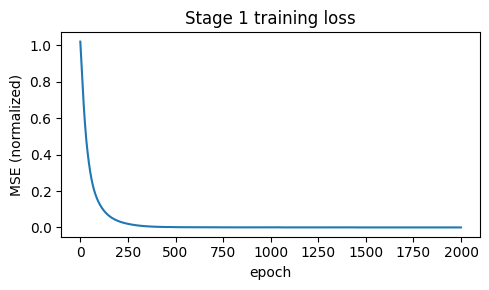

In [8]:

model_stage1 = SIREN(in_dim=2, hidden_dim=64, n_layers=4).to(device)
optimizer = torch.optim.Adam(model_stage1.parameters(), lr=1e-4)
n_epochs = 2000

losses = []
for epoch in range(n_epochs):
    optimizer.zero_grad()
    pred = model_stage1(coords_t)
    loss = nn.functional.mse_loss(pred, values_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 400 == 0:
        print(f"epoch {epoch:4d} | loss {loss.item():.6f}")

plt.figure(figsize=(5, 3))
plt.plot(losses)
plt.title("Stage 1 training loss")
plt.xlabel("epoch"); plt.ylabel("MSE (normalized)")
plt.tight_layout()
plt.savefig("stage_1_train_loss.png", dpi=300, bbox_inches="tight")
plt.show()


In [9]:

with torch.no_grad():
    recon_norm = model_stage1(coords_t).cpu().numpy().reshape(n_lat_A, n_lon_A)
recon = recon_norm * val_std + val_mean

rmse_stage1 = np.sqrt(np.mean((recon - target_2d) ** 2))
print(f"Stage 1 RMSE: {rmse_stage1:.4f} °C")

original_size = target_2d.size * 4
model_size = count_params(model_stage1) * 4
compression_ratio = original_size / model_size
print(f"Original grid size: {original_size} bytes ({target_2d.size} values)")
print(f"Model size: {model_size} bytes ({count_params(model_stage1)} parameters)")
print(f"Compression ratio: {compression_ratio:.2f}x")


Stage 1 RMSE: 0.0078 °C
Original grid size: 252 bytes (63 values)
Model size: 50948 bytes (12737 parameters)
Compression ratio: 0.00x


## A.3 Stage 2 — spatio-temporal: (lat, lon, time) → temperature, full week

In [10]:

field_flat_time = field_A
time_index = np.arange(n_time_A)

LAT3, LON3, TIME3 = np.meshgrid(lat_idx_A, lon_idx_A, time_index, indexing="ij")
lat3_norm = 2 * (LAT3 - lat_idx_A.min()) / max(lat_idx_A.max() - lat_idx_A.min(), 1) - 1
lon3_norm = 2 * (LON3 - lon_idx_A.min()) / max(lon_idx_A.max() - lon_idx_A.min(), 1) - 1
time3_norm = 2 * (TIME3 - time_index.min()) / max(time_index.max() - time_index.min(), 1) - 1

coords3 = np.stack([lat3_norm.ravel(), lon3_norm.ravel(), time3_norm.ravel()], axis=-1)
values3 = field_flat_time.ravel()

val3_mean, val3_std = values3.mean(), values3.std()
if val3_std == 0:
    val3_std = 1.0
values3_norm = (values3 - val3_mean) / val3_std

coords3_t = torch.tensor(coords3, dtype=torch.float32, device=device)
values3_t = torch.tensor(values3_norm, dtype=torch.float32, device=device).unsqueeze(-1)

print("Stage 2 total points:", coords3.shape[0], "(", n_lat_A, "x", n_lon_A, "x", n_time_A, ")")


Stage 2 total points: 10584 ( 7 x 9 x 168 )


epoch    0 | loss 0.967055
epoch  500 | loss 0.011322
epoch 1000 | loss 0.005607
epoch 1500 | loss 0.003635
epoch 2000 | loss 0.002533
epoch 2500 | loss 0.001625


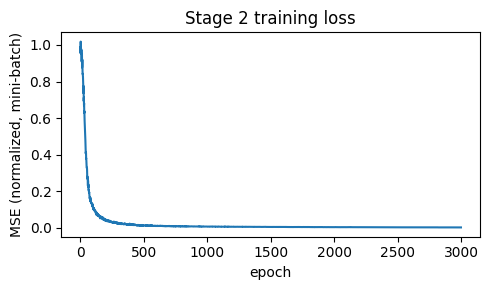

In [11]:

model_stage2 = SIREN(in_dim=3, hidden_dim=96, n_layers=5).to(device)
optimizer2 = torch.optim.Adam(model_stage2.parameters(), lr=1e-4)
n_epochs2 = 3000
batch_size = 4096
n_points = coords3_t.shape[0]

losses2 = []
for epoch in range(n_epochs2):
    idx = torch.randint(0, n_points, (batch_size,), device=device)
    optimizer2.zero_grad()
    pred = model_stage2(coords3_t[idx])
    loss = nn.functional.mse_loss(pred, values3_t[idx])
    loss.backward()
    optimizer2.step()
    losses2.append(loss.item())
    if epoch % 500 == 0:
        print(f"epoch {epoch:4d} | loss {loss.item():.6f}")

plt.figure(figsize=(5, 3))
plt.plot(losses2)
plt.title("Stage 2 training loss")
plt.xlabel("epoch"); plt.ylabel("MSE (normalized, mini-batch)")
plt.tight_layout()
plt.savefig("stage_2_train_loss.png", dpi=300, bbox_inches="tight")
plt.show()


In [12]:

with torch.no_grad():
    preds = []
    chunk = 20000
    for i in range(0, n_points, chunk):
        preds.append(model_stage2(coords3_t[i:i+chunk]).cpu().numpy())
    recon3_norm = np.concatenate(preds).reshape(n_lat_A, n_lon_A, n_time_A)
recon3 = recon3_norm * val3_std + val3_mean

rmse_stage2 = np.sqrt(np.mean((recon3 - field_flat_time) ** 2))
print(f"Stage 2 RMSE: {rmse_stage2:.4f} °C")

original_size2 = field_flat_time.size * 4
model_size2 = count_params(model_stage2) * 4
compression_ratio2 = original_size2 / model_size2
print(f"Original data size: {original_size2} bytes ({field_flat_time.size} values)")
print(f"Model size: {model_size2} bytes ({count_params(model_stage2)} parameters)")
print(f"Compression ratio: {compression_ratio2:.2f}x")


Stage 2 RMSE: 0.1227 °C
Original data size: 42336 bytes (10584 values)
Model size: 150916 bytes (37729 parameters)
Compression ratio: 0.28x



## A.4 ClimateBenchPress-style evaluation: error bounds, MaxAbsError, Spectral Error

Instead of judging RMSE against an arbitrary threshold, derive a physically grounded error
bound from ERA5's own ensemble spread (uncertainty estimate), following Reichelt et al. 2026
(ClimateBenchPress) Eq. (1)-(2). Also add MaxAbsError and Spectral Error (RAPSD) to check for
failure modes RMSE alone can hide: single-point blowups and loss of high-frequency detail.


In [13]:

if USE_SYNTHETIC_DATA:
    print("Skipping real error-bound derivation under synthetic data.")
    b_low_A = b_mid_A = b_high_A = None
else:
    spread_A = fetch_era5_ensemble_spread(REGION_A, DATE_RANGE_A, GRID_RES,
                                           cds_url=_cds_url, cds_key=_cds_key)
    spread_A = to_lat_lon_time(spread_A, lats_A, lons_A)
    b_low_A, b_mid_A, b_high_A = compute_error_bounds(spread_A)

    print("Error bounds derived from ERA5 ensemble spread (ClimateBenchPress method):")
    print(f"  b_low  (strict):  {b_low_A:.4f} °C")
    print(f"  b_mid  (medium):  {b_mid_A:.4f} °C")
    print(f"  b_high (lenient): {b_high_A:.4f} °C")
    print()
    report_against_bounds(rmse_stage2, b_low_A, b_mid_A, b_high_A, label="Stage 2 SIREN")


2026-07-23 10:25:09,897 INFO Request ID is 8dbfba9f-e2dd-4ca5-8411-a65b0af3a627
INFO:ecmwf.datastores.legacy_client:Request ID is 8dbfba9f-e2dd-4ca5-8411-a65b0af3a627
2026-07-23 10:25:10,146 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-07-23 10:25:24,058 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-07-23 10:26:01,866 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


628f6398c63ec2fc9fcc9bd8ce469a35.nc:   0%|          | 0.00/33.4k [00:00<?, ?B/s]

Downloaded and cached: /content/era5_cache/t2m_spread_40p0_41p5_27p5_29p5_2026-06-01_2026-06-07_0p25.nc
Error bounds derived from ERA5 ensemble spread (ClimateBenchPress method):
  b_low  (strict):  0.1079 °C
  b_mid  (medium):  0.1443 °C
  b_high (lenient): 0.1776 °C

Stage 2 SIREN RMSE: 0.1227 °C
  vs b_low (strict) (0.1079 °C): exceeds (1.14x the bound)
  vs b_mid (medium) (0.1443 °C): PASSES (0.85x the bound)
  vs b_high (lenient) (0.1776 °C): PASSES (0.69x the bound)


In [14]:

max_err_A = max_abs_error(field_flat_time, recon3)
spec_err_A = spectral_error(field_flat_time, recon3)

print(f"Stage 2 SIREN -- MaxAbsError: {max_err_A:.4f} °C  (RMSE was {rmse_stage2:.4f} °C)")
print(f"Stage 2 SIREN -- Spectral Error (RAPSD, ClimateBenchPress convention): {spec_err_A:.6f}")


Stage 2 SIREN -- MaxAbsError: 0.8285 °C  (RMSE was 0.1227 °C)
Stage 2 SIREN -- Spectral Error (RAPSD, ClimateBenchPress convention): 23571.628906


## A.5 Baseline comparison: PCA (single setting)

In [15]:

X_A = field_flat_time.reshape(n_lat_A * n_lon_A, n_time_A).T
n_components_A = min(5, X_A.shape[0], X_A.shape[1])
pca_A = PCA(n_components=n_components_A)
X_reduced_A = pca_A.fit_transform(X_A)
X_reconstructed_A = pca_A.inverse_transform(X_reduced_A)

rmse_pca_A = np.sqrt(np.mean((X_reconstructed_A - X_A) ** 2))
pca_size_A = (pca_A.components_.size + pca_A.mean_.size + X_reduced_A.size) * 4
compression_ratio_pca_A = original_size2 / pca_size_A

print(f"PCA RMSE ({n_components_A} components): {rmse_pca_A:.4f} °C")
print(f"PCA representation size: {pca_size_A} bytes")
print(f"PCA compression ratio: {compression_ratio_pca_A:.2f}x")

print("\n--- Part A summary ---")
print(f"{'Method':<20}{'RMSE (°C)':<15}{'Compression ratio':<20}")
print(f"{'SIREN (Stage 2)':<20}{rmse_stage2:<15.4f}{compression_ratio2:<20.2f}")
print(f"{'PCA (' + str(n_components_A) + ' comps)':<20}{rmse_pca_A:<15.4f}{compression_ratio_pca_A:<20.2f}")

if not USE_SYNTHETIC_DATA:
    print()
    report_against_bounds(rmse_pca_A, b_low_A, b_mid_A, b_high_A, label="PCA")


PCA RMSE (5 components): 0.3839 °C
PCA representation size: 4872 bytes
PCA compression ratio: 8.69x

--- Part A summary ---
Method              RMSE (°C)      Compression ratio   
SIREN (Stage 2)     0.1227         0.28                
PCA (5 comps)       0.3839         8.69                

PCA RMSE: 0.3839 °C
  vs b_low (strict) (0.1079 °C): exceeds (3.56x the bound)
  vs b_mid (medium) (0.1443 °C): exceeds (2.66x the bound)
  vs b_high (lenient) (0.1776 °C): exceeds (2.16x the bound)



## A.6 Diagnostics: Fourier spectrum, spatial correlation, Taylor diagram


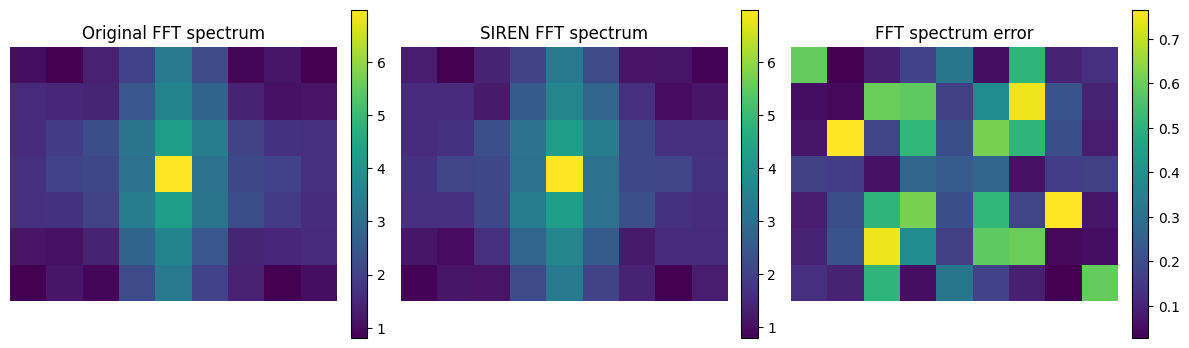

In [16]:

t_show = 0
true_2d = field_flat_time[:, :, t_show]
recon_2d = recon3[:, :, t_show]

fft_true = np.fft.fftshift(np.abs(np.fft.fft2(true_2d)))
fft_recon = np.fft.fftshift(np.abs(np.fft.fft2(recon_2d)))
fft_error = np.abs(fft_recon - fft_true)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
im0 = axes[0].imshow(np.log1p(fft_true)); axes[0].set_title("Original FFT spectrum"); axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
im1 = axes[1].imshow(np.log1p(fft_recon)); axes[1].set_title("SIREN FFT spectrum"); axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
im2 = axes[2].imshow(np.log1p(fft_error)); axes[2].set_title("FFT spectrum error"); axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("fourier_spectrum.png", dpi=300, bbox_inches="tight")
plt.show()


Mean spatial correlation: 0.9975
Min spatial correlation: 0.9652
Max spatial correlation: 0.9998


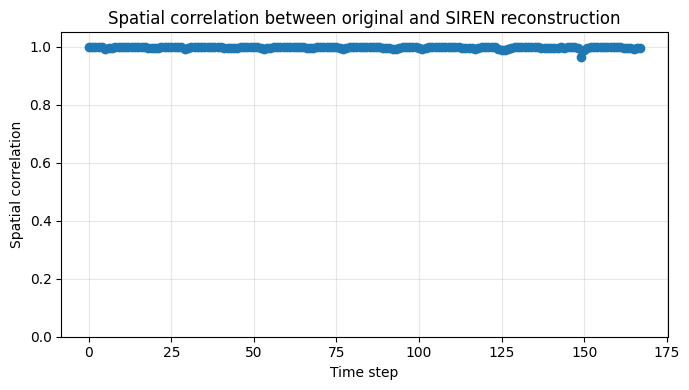

In [17]:

corrs = np.array([np.corrcoef(field_flat_time[:, :, t].ravel(), recon3[:, :, t].ravel())[0, 1]
                   for t in range(n_time_A)])

print(f"Mean spatial correlation: {corrs.mean():.4f}")
print(f"Min spatial correlation: {corrs.min():.4f}")
print(f"Max spatial correlation: {corrs.max():.4f}")

plt.figure(figsize=(7, 4))
plt.plot(np.arange(n_time_A), corrs, marker="o")
plt.xlabel("Time step"); plt.ylabel("Spatial correlation")
plt.title("Spatial correlation between original and SIREN reconstruction")
plt.ylim(0, 1.05); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("spatial_correlation.png", dpi=300, bbox_inches="tight")
plt.show()


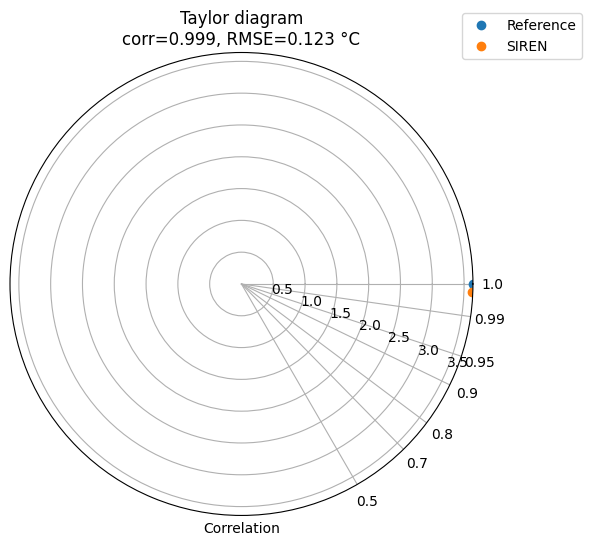

In [18]:

def taylor_stats(reference, prediction):
    ref, pred = reference.ravel(), prediction.ravel()
    corr = np.corrcoef(ref, pred)[0, 1]
    return corr, np.std(ref), np.std(pred), np.sqrt(np.mean((pred - ref) ** 2))

corr, std_ref, std_pred, rmse_t = taylor_stats(field_flat_time, recon3)
theta = np.arccos(corr)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, polar=True)
ax.plot(0, std_ref, "o", label="Reference")
ax.plot(theta, std_pred, "o", label="SIREN")
ax.set_theta_zero_location("E"); ax.set_theta_direction(-1)
corr_ticks = np.array([0.5, 0.7, 0.8, 0.9, 0.95, 0.99, 1.0])
ax.set_thetagrids(np.degrees(np.arccos(corr_ticks)), labels=[str(c) for c in corr_ticks])
ax.set_xlabel("Correlation")
ax.set_title(f"Taylor diagram\ncorr={corr:.3f}, RMSE={rmse_t:.3f} °C")
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))
plt.tight_layout()
plt.savefig("taylor_diagram.png", dpi=300, bbox_inches="tight")
plt.show()



## A.7 What a stored array can't do: super-resolution, time interpolation, gradients


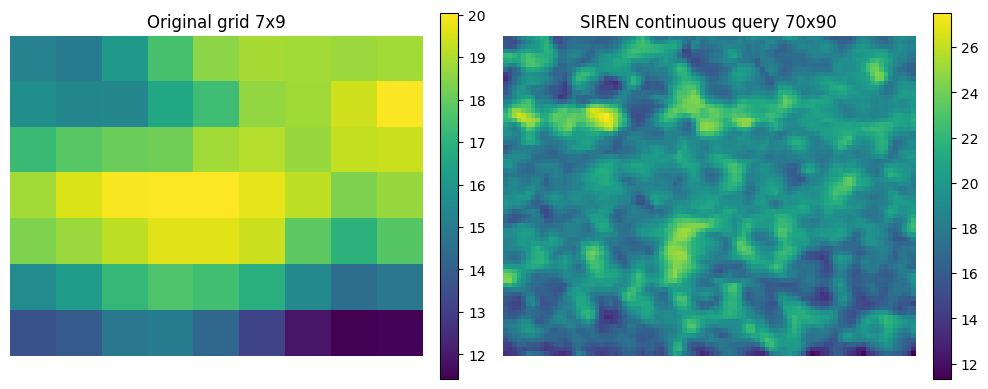

In [19]:

def siren_predict_grid(model, n_lat_hr, n_lon_hr, t_norm_value, val_mean, val_std):
    lat_hr = np.linspace(-1, 1, n_lat_hr)
    lon_hr = np.linspace(-1, 1, n_lon_hr)
    LAT_HR, LON_HR = np.meshgrid(lat_hr, lon_hr, indexing="ij")
    TIME_HR = np.full_like(LAT_HR, t_norm_value)
    coords_hr = np.stack([LAT_HR.ravel(), LON_HR.ravel(), TIME_HR.ravel()], axis=-1)
    coords_hr_t = torch.tensor(coords_hr, dtype=torch.float32, device=device)
    with torch.no_grad():
        pred_hr_norm = model(coords_hr_t).cpu().numpy().reshape(n_lat_hr, n_lon_hr)
    return pred_hr_norm * val_std + val_mean


t_show = 0
t_norm_value = 2 * (t_show - 0) / (n_time_A - 1) - 1
super_lat, super_lon = n_lat_A * 10, n_lon_A * 10

recon_super = siren_predict_grid(model_stage2, super_lat, super_lon, t_norm_value, val3_mean, val3_std)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im0 = axes[0].imshow(field_flat_time[:, :, t_show]); axes[0].set_title(f"Original grid {n_lat_A}x{n_lon_A}"); axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
im1 = axes[1].imshow(recon_super); axes[1].set_title(f"SIREN continuous query {super_lat}x{super_lon}"); axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("cont_interpolation.png", dpi=300, bbox_inches="tight")
plt.show()


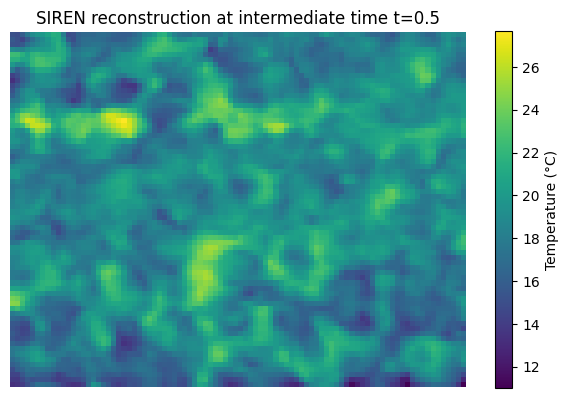

In [20]:

t_between = 0.5
t_norm_between = 2 * t_between / (n_time_A - 1) - 1
recon_between = siren_predict_grid(model_stage2, super_lat, super_lon, t_norm_between, val3_mean, val3_std)

plt.figure(figsize=(6, 4))
plt.imshow(recon_between)
plt.title("SIREN reconstruction at intermediate time t=0.5")
plt.axis("off")
plt.colorbar(label="Temperature (°C)")
plt.tight_layout()
plt.savefig("time_interpolation.png", dpi=300, bbox_inches="tight")
plt.show()


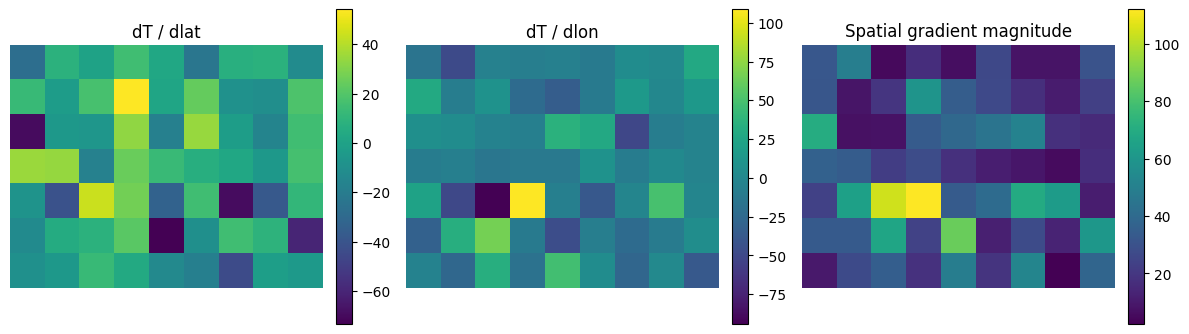

In [21]:

t_norm_value = 2 * 0 / (n_time_A - 1) - 1
lat_grid_n = np.linspace(-1, 1, n_lat_A)
lon_grid_n = np.linspace(-1, 1, n_lon_A)
LAT_G, LON_G = np.meshgrid(lat_grid_n, lon_grid_n, indexing="ij")
TIME_G = np.full_like(LAT_G, t_norm_value)
coords_grad = np.stack([LAT_G.ravel(), LON_G.ravel(), TIME_G.ravel()], axis=-1)
coords_grad_t = torch.tensor(coords_grad, dtype=torch.float32, device=device, requires_grad=True)

pred_norm = model_stage2(coords_grad_t)
pred = pred_norm * val3_std + val3_mean
grads = torch.autograd.grad(outputs=pred, inputs=coords_grad_t,
                              grad_outputs=torch.ones_like(pred), create_graph=False)[0]

dT_dlat = grads[:, 0].detach().cpu().numpy().reshape(n_lat_A, n_lon_A)
dT_dlon = grads[:, 1].detach().cpu().numpy().reshape(n_lat_A, n_lon_A)
grad_mag = np.sqrt(dT_dlat**2 + dT_dlon**2)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
im0 = axes[0].imshow(dT_dlat); axes[0].set_title("dT / dlat"); axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
im1 = axes[1].imshow(dT_dlon); axes[1].set_title("dT / dlon"); axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
im2 = axes[2].imshow(grad_mag); axes[2].set_title("Spatial gradient magnitude"); axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("spatial_gradient.png", dpi=300, bbox_inches="tight")
plt.show()



---
# Part B: Large-scale experiment — does compression ever actually win?

~125x more data than Part A (wider region, one full month, hourly). Sweeps small SIREN
architectures against a multi-point PCA baseline to find where, if anywhere, INR compression
crosses the 1x break-even point and how it compares to PCA's own ceiling.


## B.1 Data

In [22]:

lats_B, lons_B = build_grid(REGION_B, GRID_RES)

if USE_SYNTHETIC_DATA:
    print("Using synthetic fallback data -- for structural testing only.")
    field_B = synthetic_t2m_field(lats_B, lons_B, 24 * 30)
else:
    raw_B, data_lats_B, data_lons_B = fetch_era5_t2m(REGION_B, DATE_RANGE_B, GRID_RES,
                                                       cds_url=_cds_url, cds_key=_cds_key)
    field_B = to_lat_lon_time(raw_B, data_lats_B, data_lons_B)
    lats_B, lons_B = data_lats_B, data_lons_B

n_lat_B, n_lon_B, n_time_B = field_B.shape
n_values_B = field_B.size
print(f"Part B field shape (lat, lon, time): {field_B.shape}")
print(f"Total values: {n_values_B:,}  (~{n_values_B * 4 / 1024:.1f} KB as float32)")


2026-07-23 10:26:09,074 INFO Request ID is fea8fa85-f052-4034-82e4-db7c0932410a
INFO:ecmwf.datastores.legacy_client:Request ID is fea8fa85-f052-4034-82e4-db7c0932410a
2026-07-23 10:26:10,304 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-07-23 10:26:24,188 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-07-23 10:26:31,923 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


2e9804fb73f0343afe2e23e76d14f0eb.nc:   0%|          | 0.00/501k [00:00<?, ?B/s]

Downloaded and cached: /content/era5_cache/t2m_38p5_42p5_26p0_31p0_2026-06-01_2026-06-30_0p25.nc
Part B field shape (lat, lon, time): (17, 21, 720)
Total values: 257,040  (~1004.1 KB as float32)


## B.2 Coordinate/value dataset

In [23]:

lat_idx_B = np.arange(n_lat_B)
lon_idx_B = np.arange(n_lon_B)
time_idx_B = np.arange(n_time_B)

LAT3_B, LON3_B, TIME3_B = np.meshgrid(lat_idx_B, lon_idx_B, time_idx_B, indexing="ij")
lat_norm_B = 2 * (LAT3_B - lat_idx_B.min()) / max(lat_idx_B.max() - lat_idx_B.min(), 1) - 1
lon_norm_B = 2 * (LON3_B - lon_idx_B.min()) / max(lon_idx_B.max() - lon_idx_B.min(), 1) - 1
time_norm_B = 2 * (TIME3_B - time_idx_B.min()) / max(time_idx_B.max() - time_idx_B.min(), 1) - 1

coords_B = np.stack([lat_norm_B.ravel(), lon_norm_B.ravel(), time_norm_B.ravel()], axis=-1)
values_B = field_B.ravel()

val_mean_B, val_std_B = values_B.mean(), values_B.std()
if val_std_B == 0:
    val_std_B = 1.0
values_norm_B = (values_B - val_mean_B) / val_std_B

coords_t_B = torch.tensor(coords_B, dtype=torch.float32, device=device)
values_t_B = torch.tensor(values_norm_B, dtype=torch.float32, device=device).unsqueeze(-1)

n_points_B = coords_t_B.shape[0]
original_size_bytes_B = field_B.size * 4
print(f"Total points: {n_points_B:,}")
print(f"Original data size: {original_size_bytes_B:,} bytes ({original_size_bytes_B / 1024:.1f} KB)")


Total points: 257,040
Original data size: 1,028,160 bytes (1004.1 KB)



## B.3 Architecture sweep: small SIRENs vs. RMSE vs. compression ratio

Trained long enough to actually converge (20,000 epochs, cosine-annealed LR) -- a first pass at
3,000 epochs visibly under-trained the larger architectures here.


In [24]:

def train_siren(coords_t, values_t, hidden_dim, n_layers, n_epochs=20000, batch_size=16384,
                 lr=2e-3, log_every=2000, seed=0, return_losses=False):
    """Train a SIREN. `seed` is set locally (not relying on the notebook's global RNG
    state) so that re-running this function later in the notebook -- e.g. with a
    different n_epochs -- is reproducible and comparable to earlier runs of the same
    architecture, rather than silently depending on how much other randomness has been
    consumed elsewhere in the session by that point."""
    torch.manual_seed(seed)
    model = SIREN(in_dim=3, hidden_dim=hidden_dim, n_layers=n_layers).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    n_pts = coords_t.shape[0]
    bs = min(batch_size, n_pts)

    losses = []
    for epoch in range(n_epochs):
        idx = torch.randint(0, n_pts, (bs,), device=device)
        optimizer.zero_grad()
        pred = model(coords_t[idx])
        loss = nn.functional.mse_loss(pred, values_t[idx])
        loss.backward()
        optimizer.step()
        scheduler.step()
        losses.append(loss.item())
        if epoch % log_every == 0:
            print(f"    epoch {epoch:5d} | loss {loss.item():.6f} | lr {scheduler.get_last_lr()[0]:.2e}")
    if return_losses:
        return model, losses
    return model


def evaluate_siren(model, coords_t, values_raw, val_mean, val_std, chunk=50000):
    n_pts = coords_t.shape[0]
    preds = []
    with torch.no_grad():
        for i in range(0, n_pts, chunk):
            preds.append(model(coords_t[i:i+chunk]).cpu().numpy())
    recon_norm = np.concatenate(preds, axis=0).ravel()
    recon = recon_norm * val_std + val_mean
    rmse = np.sqrt(np.mean((recon - values_raw) ** 2))
    return rmse, recon


architectures = [
    {"hidden_dim": 16, "n_layers": 2},
    {"hidden_dim": 24, "n_layers": 2},
    {"hidden_dim": 32, "n_layers": 3},
    {"hidden_dim": 48, "n_layers": 3},
    {"hidden_dim": 48, "n_layers": 4},
]

sweep_results = []
values_raw_B = field_B.ravel()

for arch in architectures:
    print(f"Training SIREN hidden_dim={arch['hidden_dim']}, n_layers={arch['n_layers']}...")
    model = train_siren(coords_t_B, values_t_B, arch["hidden_dim"], arch["n_layers"], seed=0)
    rmse, recon_flat = evaluate_siren(model, coords_t_B, values_raw_B, val_mean_B, val_std_B)

    n_params = count_params(model)
    size_fp32 = model_size_bytes(model, dtype_bytes=4)
    size_fp16 = model_size_bytes(model, dtype_bytes=2)
    ratio_fp32 = original_size_bytes_B / size_fp32
    ratio_fp16 = original_size_bytes_B / size_fp16

    sweep_results.append({
        "hidden_dim": arch["hidden_dim"], "n_layers": arch["n_layers"], "n_params": n_params,
        "rmse": rmse, "size_fp32_bytes": size_fp32, "size_fp16_bytes": size_fp16,
        "ratio_fp32": ratio_fp32, "ratio_fp16": ratio_fp16, "model": model,
        "recon_flat": recon_flat,
    })
    print(f"    -> RMSE {rmse:.4f} °C | params {n_params:,} | "
          f"ratio(fp32) {ratio_fp32:.2f}x | ratio(fp16) {ratio_fp16:.2f}x")


Training SIREN hidden_dim=16, n_layers=2...
    epoch     0 | loss 1.004070 | lr 2.00e-03
    epoch  2000 | loss 0.668893 | lr 1.95e-03
    epoch  4000 | loss 0.648457 | lr 1.81e-03
    epoch  6000 | loss 0.631677 | lr 1.59e-03
    epoch  8000 | loss 0.636249 | lr 1.31e-03
    epoch 10000 | loss 0.549125 | lr 1.00e-03
    epoch 12000 | loss 0.539693 | lr 6.91e-04
    epoch 14000 | loss 0.533291 | lr 4.12e-04
    epoch 16000 | loss 0.530244 | lr 1.91e-04
    epoch 18000 | loss 0.534791 | lr 4.89e-05
    -> RMSE 3.1977 °C | params 353 | ratio(fp32) 728.16x | ratio(fp16) 1456.32x
Training SIREN hidden_dim=24, n_layers=2...
    epoch     0 | loss 1.028370 | lr 2.00e-03
    epoch  2000 | loss 0.718369 | lr 1.95e-03
    epoch  4000 | loss 0.711131 | lr 1.81e-03
    epoch  6000 | loss 0.695134 | lr 1.59e-03
    epoch  8000 | loss 0.705826 | lr 1.31e-03
    epoch 10000 | loss 0.692414 | lr 1.00e-03
    epoch 12000 | loss 0.696553 | lr 6.91e-04
    epoch 14000 | loss 0.703014 | lr 4.12e-04
    

In [25]:

print(f"{'hidden':<8}{'layers':<8}{'params':<10}{'RMSE (°C)':<12}{'ratio fp32':<12}{'ratio fp16':<12}")
for r in sweep_results:
    print(f"{r['hidden_dim']:<8}{r['n_layers']:<8}{r['n_params']:<10,}{r['rmse']:<12.4f}"
          f"{r['ratio_fp32']:<12.2f}{r['ratio_fp16']:<12.2f}")


hidden  layers  params    RMSE (°C)   ratio fp32  ratio fp16  
16      2       353       3.1977      728.16      1456.32     
24      2       721       3.6637      356.50      713.01      
32      3       2,273     1.2658      113.08      226.17      
48      3       4,945     0.7915      51.98       103.96      
48      4       7,297     1.0040      35.23       70.45       


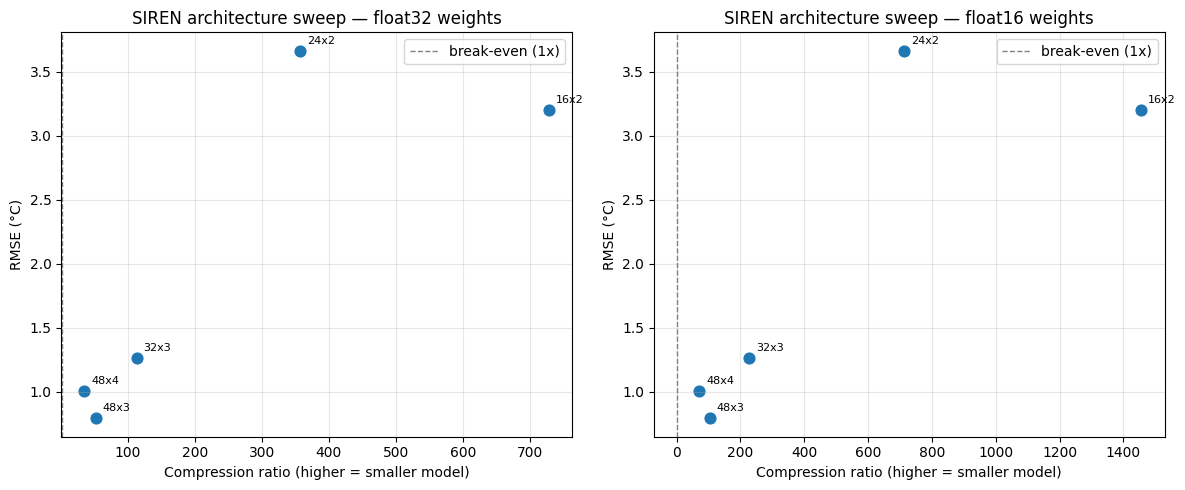

In [26]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, key, label in [(axes[0], "ratio_fp32", "float32 weights"), (axes[1], "ratio_fp16", "float16 weights")]:
    ratios = [r[key] for r in sweep_results]
    rmses = [r["rmse"] for r in sweep_results]
    labels = [f"{r['hidden_dim']}x{r['n_layers']}" for r in sweep_results]
    ax.scatter(ratios, rmses, s=60)
    for x, y, lab in zip(ratios, rmses, labels):
        ax.annotate(lab, (x, y), textcoords="offset points", xytext=(5, 5), fontsize=8)
    ax.axvline(1.0, color="gray", linestyle="--", linewidth=1, label="break-even (1x)")
    ax.set_xlabel("Compression ratio (higher = smaller model)")
    ax.set_ylabel("RMSE (°C)")
    ax.set_title(f"SIREN architecture sweep — {label}")
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("siren_architecture_pareto.png", dpi=300, bbox_inches="tight")
plt.show()


## B.4 PCA baseline at multiple component counts

In [27]:

X_B = field_B.reshape(n_lat_B * n_lon_B, n_time_B).T
component_counts = [c for c in [1, 2, 3, 5, 8, 12, 20] if c <= min(X_B.shape[0], X_B.shape[1])]

pca_results = []
for k in component_counts:
    pca = PCA(n_components=k)
    X_reduced = pca.fit_transform(X_B)
    X_reconstructed = pca.inverse_transform(X_reduced)
    rmse_pca = np.sqrt(np.mean((X_reconstructed - X_B) ** 2))
    pca_size = (pca.components_.size + pca.mean_.size + X_reduced.size) * 4
    ratio_pca = original_size_bytes_B / pca_size

    pca_results.append({"n_components": k, "rmse": rmse_pca, "size_bytes": pca_size,
                         "ratio": ratio_pca, "X_reconstructed": X_reconstructed})
    print(f"PCA k={k:<3} | RMSE {rmse_pca:.4f} °C | size {pca_size:,} bytes | ratio {ratio_pca:.2f}x")


PCA k=1   | RMSE 1.3089 °C | size 5,736 bytes | ratio 179.25x
PCA k=2   | RMSE 0.9695 °C | size 10,044 bytes | ratio 102.37x
PCA k=3   | RMSE 0.8056 °C | size 14,352 bytes | ratio 71.64x
PCA k=5   | RMSE 0.6110 °C | size 22,968 bytes | ratio 44.76x
PCA k=8   | RMSE 0.5091 °C | size 35,892 bytes | ratio 28.65x
PCA k=12  | RMSE 0.4217 °C | size 53,124 bytes | ratio 19.35x
PCA k=20  | RMSE 0.3190 °C | size 87,588 bytes | ratio 11.74x


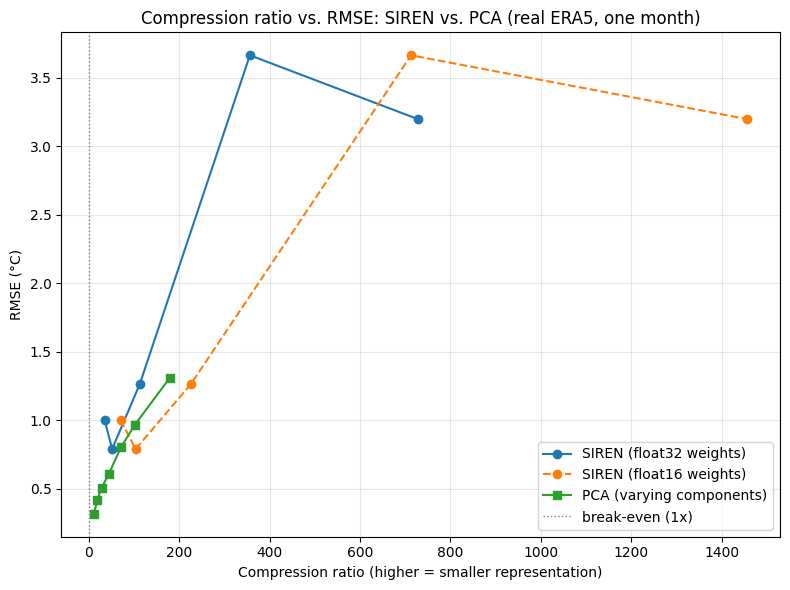

In [28]:

fig, ax = plt.subplots(figsize=(8, 6))
siren_ratios_fp32 = [r["ratio_fp32"] for r in sweep_results]
siren_rmses = [r["rmse"] for r in sweep_results]
siren_ratios_fp16 = [r["ratio_fp16"] for r in sweep_results]
pca_ratios = [r["ratio"] for r in pca_results]
pca_rmses = [r["rmse"] for r in pca_results]

ax.plot(sorted(siren_ratios_fp32), [x for _, x in sorted(zip(siren_ratios_fp32, siren_rmses))], "o-", label="SIREN (float32 weights)")
ax.plot(sorted(siren_ratios_fp16), [x for _, x in sorted(zip(siren_ratios_fp16, siren_rmses))], "o--", label="SIREN (float16 weights)")
ax.plot(sorted(pca_ratios), [x for _, x in sorted(zip(pca_ratios, pca_rmses))], "s-", label="PCA (varying components)")
ax.axvline(1.0, color="gray", linestyle=":", linewidth=1, label="break-even (1x)")
ax.set_xlabel("Compression ratio (higher = smaller representation)")
ax.set_ylabel("RMSE (°C)")
ax.set_title("Compression ratio vs. RMSE: SIREN vs. PCA (real ERA5, one month)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("siren_vs_pca_pareto.png", dpi=300, bbox_inches="tight")
plt.show()



## B.5 ClimateBenchPress-style re-reporting: sweep results against a real error bound

Derive the same kind of physically grounded error bound as in Part A, but for the Part B
region/period, and re-report the architecture sweep and PCA sweep as **pass/fail against that
bound**, then find the best achievable compression ratio per method that still stays inside it.
This reframes "best compression" from a raw ratio into a claim that's actually defensible
against ERA5's own uncertainty.


In [29]:

if USE_SYNTHETIC_DATA:
    print("Skipping real error-bound derivation under synthetic data.")
    b_low_B = b_mid_B = b_high_B = None
else:
    spread_B = fetch_era5_ensemble_spread(REGION_B, DATE_RANGE_B, GRID_RES,
                                           cds_url=_cds_url, cds_key=_cds_key)
    spread_B = to_lat_lon_time(spread_B, lats_B, lons_B)
    b_low_B, b_mid_B, b_high_B = compute_error_bounds(spread_B)
    print(f"Part B error bounds: low={b_low_B:.4f}°C, mid={b_mid_B:.4f}°C, high={b_high_B:.4f}°C")


2026-07-23 10:29:48,379 INFO Request ID is fc9db922-49a5-4f34-bbd3-63d4e90d3706
INFO:ecmwf.datastores.legacy_client:Request ID is fc9db922-49a5-4f34-bbd3-63d4e90d3706
2026-07-23 10:29:48,547 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-07-23 10:30:12,743 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-07-23 10:30:41,571 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


423eeba58e0eec5423b2e52a8ba108a9.nc:   0%|          | 0.00/230k [00:00<?, ?B/s]

Downloaded and cached: /content/era5_cache/t2m_spread_38p5_42p5_26p0_31p0_2026-06-01_2026-06-30_0p25.nc
Part B error bounds: low=0.0685°C, mid=0.1327°C, high=0.1804°C


In [30]:

if not USE_SYNTHETIC_DATA:
    print(f"{'Method':<24}{'RMSE (°C)':<12}{'Ratio':<10}{'Passes b_low':<14}{'Passes b_mid':<14}{'Passes b_high':<14}")
    for r in sweep_results:
        label = f"SIREN {r['hidden_dim']}x{r['n_layers']}"
        print(f"{label:<24}{r['rmse']:<12.4f}{r['ratio_fp32']:<10.1f}"
              f"{'YES' if r['rmse']<=b_low_B else 'no':<14}"
              f"{'YES' if r['rmse']<=b_mid_B else 'no':<14}"
              f"{'YES' if r['rmse']<=b_high_B else 'no':<14}")
    for r in pca_results:
        label = f"PCA k={r['n_components']}"
        print(f"{label:<24}{r['rmse']:<12.4f}{r['ratio']:<10.1f}"
              f"{'YES' if r['rmse']<=b_low_B else 'no':<14}"
              f"{'YES' if r['rmse']<=b_mid_B else 'no':<14}"
              f"{'YES' if r['rmse']<=b_high_B else 'no':<14}")

    def best_ratio_passing(results, rmse_key, ratio_key, bound):
        passing = [r for r in results if r[rmse_key] <= bound]
        return max(passing, key=lambda r: r[ratio_key]) if passing else None

    print("\n--- Best compression ratio that still passes each bound ---")
    for bound_name, bound_val in [("b_low", b_low_B), ("b_mid", b_mid_B), ("b_high", b_high_B)]:
        best_siren = best_ratio_passing(sweep_results, "rmse", "ratio_fp32", bound_val)
        best_pca = best_ratio_passing(pca_results, "rmse", "ratio", bound_val)
        print(f"\n{bound_name} ({bound_val:.4f}°C):")
        print(f"  SIREN: {best_siren['ratio_fp32']:.1f}x" if best_siren else "  SIREN: none pass")
        print(f"  PCA:   {best_pca['ratio']:.1f}x" if best_pca else "  PCA: none pass")


Method                  RMSE (°C)   Ratio     Passes b_low  Passes b_mid  Passes b_high 
SIREN 16x2              3.1977      728.2     no            no            no            
SIREN 24x2              3.6637      356.5     no            no            no            
SIREN 32x3              1.2658      113.1     no            no            no            
SIREN 48x3              0.7915      52.0      no            no            no            
SIREN 48x4              1.0040      35.2      no            no            no            
PCA k=1                 1.3089      179.2     no            no            no            
PCA k=2                 0.9695      102.4     no            no            no            
PCA k=3                 0.8056      71.6      no            no            no            
PCA k=5                 0.6110      44.8      no            no            no            
PCA k=8                 0.5091      28.6      no            no            no            
PCA k=12             

In [31]:

if not USE_SYNTHETIC_DATA:
    # Spectral error and MaxAbsError for the best (lowest RMSE) architecture in the sweep,
    # to check whether high-frequency detail and worst-case error behave reasonably at this scale.
    best_arch = min(sweep_results, key=lambda r: r["rmse"])
    recon_3d_best = best_arch["recon_flat"].reshape(n_lat_B, n_lon_B, n_time_B)

    max_err_B = max_abs_error(field_B, recon_3d_best)
    spec_err_B = spectral_error(field_B, recon_3d_best)

    print(f"Best architecture: {best_arch['hidden_dim']}x{best_arch['n_layers']} "
          f"(RMSE {best_arch['rmse']:.4f} °C)")
    print(f"MaxAbsError: {max_err_B:.4f} °C")
    print(f"Spectral Error (RAPSD): {spec_err_B:.6f}")


Best architecture: 48x3 (RMSE 0.7915 °C)
MaxAbsError: 4.9711 °C
Spectral Error (RAPSD): 20477392.000000



## B.6 Quantization sanity check: does float16 actually hurt accuracy?


In [32]:

rmse_threshold = np.percentile([r["rmse"] for r in sweep_results], 75)
candidates = [r for r in sweep_results if r["rmse"] <= rmse_threshold]
best = max(candidates, key=lambda r: r["ratio_fp16"]) if candidates else sweep_results[0]

print(f"Selected architecture: hidden_dim={best['hidden_dim']}, n_layers={best['n_layers']} "
      f"(fp32 RMSE {best['rmse']:.4f} °C, ratio_fp16 {best['ratio_fp16']:.2f}x)")

model_fp16 = best["model"].half()
coords_fp16 = coords_t_B.half()

preds = []
chunk = 50000
with torch.no_grad():
    for i in range(0, coords_fp16.shape[0], chunk):
        preds.append(model_fp16(coords_fp16[i:i+chunk]).float().cpu().numpy())
recon_fp16_norm = np.concatenate(preds, axis=0).ravel()
recon_fp16 = recon_fp16_norm * val_std_B + val_mean_B

rmse_fp16_actual = np.sqrt(np.mean((recon_fp16 - values_raw_B) ** 2))
print(f"RMSE at float32 precision: {best['rmse']:.4f} °C")
print(f"RMSE at float16 precision (actual): {rmse_fp16_actual:.4f} °C")
print(f"Degradation from quantization: {rmse_fp16_actual - best['rmse']:.4f} °C")


Selected architecture: hidden_dim=16, n_layers=2 (fp32 RMSE 3.1977 °C, ratio_fp16 1456.32x)
RMSE at float32 precision: 3.1977 °C
RMSE at float16 precision (actual): 3.1994 °C
Degradation from quantization: 0.0018 °C



---
# Part C: Chasing down the open questions

Part B left several things unresolved: whether more training would close the gap to the
error bound, whether the deep-SIREN training failure could be fixed at its root cause rather
than avoided, whether results are stable across random seeds, and whether the
super-resolution/interpolation capability from Part A survives at Part B's scale and
narrower architectures. This section works through each of those in turn.



## C.1 Extended PCA sweep: where does compression actually satisfy the error bound?

The original PCA sweep (Section B.4) only explored k up to 20 components, all of which failed
every error bound. Here we push k much further to find the actual crossing point.


In [33]:
# --- Extended PCA sweep: push k much higher to find where (if anywhere) it crosses b_high ---
max_possible_k = min(X_B.shape[0], X_B.shape[1])
extended_component_counts = [1, 2, 3, 5, 8, 12, 20, 30, 50, 75, 100, 150, 200,
                              min(300, max_possible_k), max_possible_k]
extended_component_counts = sorted(set(c for c in extended_component_counts if c <= max_possible_k))

pca_results_extended = []
for k in extended_component_counts:
    pca = PCA(n_components=k)
    X_reduced = pca.fit_transform(X_B)
    X_reconstructed = pca.inverse_transform(X_reduced)
    rmse_pca = np.sqrt(np.mean((X_reconstructed - X_B) ** 2))
    pca_size = (pca.components_.size + pca.mean_.size + X_reduced.size) * 4
    ratio_pca = original_size_bytes_B / pca_size

    pca_results_extended.append({"n_components": k, "rmse": rmse_pca, "ratio": ratio_pca})
    passes_high = "PASSES b_high" if rmse_pca <= b_high_B else ""
    print(f"PCA k={k:<4} | RMSE {rmse_pca:.4f} °C | ratio {ratio_pca:.2f}x  {passes_high}")

# --- Find the crossing point: smallest k that satisfies each bound ---
print("\n--- Smallest k (= lowest compression) that satisfies each bound ---")
for bound_name, bound_val in [("b_low", b_low_B), ("b_mid", b_mid_B), ("b_high", b_high_B)]:
    passing = [r for r in pca_results_extended if r["rmse"] <= bound_val]
    if passing:
        best = min(passing, key=lambda r: r["n_components"])  # smallest k that still passes
        print(f"{bound_name} ({bound_val:.4f}°C): k={best['n_components']}, "
              f"ratio={best['ratio']:.2f}x, RMSE={best['rmse']:.4f}°C")
    else:
        print(f"{bound_name} ({bound_val:.4f}°C): no k up to {max_possible_k} passes")

PCA k=1    | RMSE 1.3089 °C | ratio 179.25x  
PCA k=2    | RMSE 0.9695 °C | ratio 102.37x  
PCA k=3    | RMSE 0.8056 °C | ratio 71.64x  
PCA k=5    | RMSE 0.6110 °C | ratio 44.76x  
PCA k=8    | RMSE 0.5091 °C | ratio 28.65x  
PCA k=12   | RMSE 0.4217 °C | ratio 19.35x  
PCA k=20   | RMSE 0.3190 °C | ratio 11.74x  
PCA k=30   | RMSE 0.2489 °C | ratio 7.87x  
PCA k=50   | RMSE 0.1675 °C | ratio 4.74x  PASSES b_high
PCA k=75   | RMSE 0.1113 °C | ratio 3.17x  PASSES b_high
PCA k=100  | RMSE 0.0763 °C | ratio 2.38x  PASSES b_high
PCA k=150  | RMSE 0.0342 °C | ratio 1.59x  PASSES b_high
PCA k=200  | RMSE 0.0113 °C | ratio 1.19x  PASSES b_high
PCA k=300  | RMSE 0.0001 °C | ratio 0.79x  PASSES b_high
PCA k=357  | RMSE 0.0000 °C | ratio 0.67x  PASSES b_high

--- Smallest k (= lowest compression) that satisfies each bound ---
b_low (0.0685°C): k=150, ratio=1.59x, RMSE=0.0342°C
b_mid (0.1327°C): k=75, ratio=3.17x, RMSE=0.1113°C
b_high (0.1804°C): k=50, ratio=4.74x, RMSE=0.1675°C


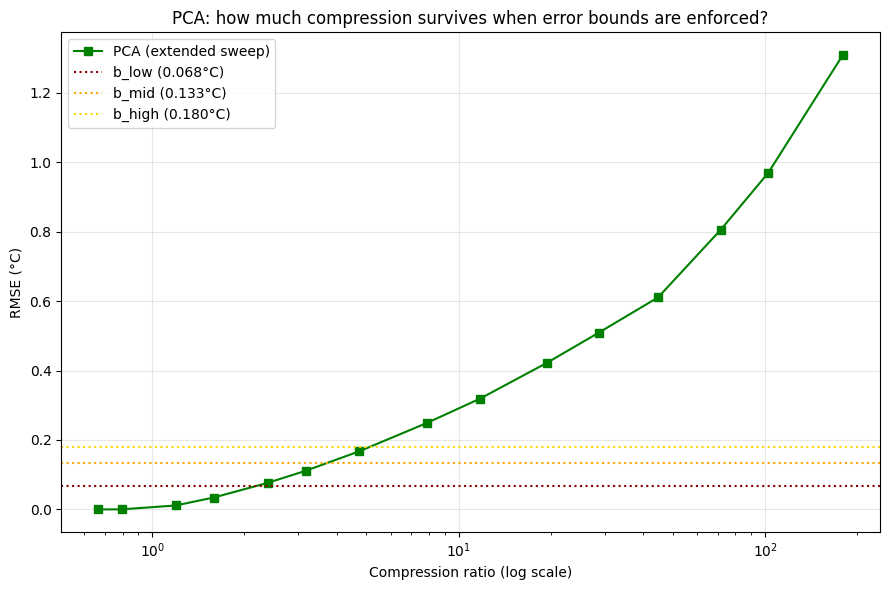

In [34]:
fig, ax = plt.subplots(figsize=(9, 6))
ratios_ext = [r["ratio"] for r in pca_results_extended]
rmses_ext = [r["rmse"] for r in pca_results_extended]

ax.plot(ratios_ext, rmses_ext, "s-", color="green", label="PCA (extended sweep)")
ax.axhline(b_low_B, color="darkred", linestyle=":", label=f"b_low ({b_low_B:.3f}°C)")
ax.axhline(b_mid_B, color="orange", linestyle=":", label=f"b_mid ({b_mid_B:.3f}°C)")
ax.axhline(b_high_B, color="gold", linestyle=":", label=f"b_high ({b_high_B:.3f}°C)")
ax.set_xscale("log")
ax.set_xlabel("Compression ratio (log scale)")
ax.set_ylabel("RMSE (°C)")
ax.set_title("PCA: how much compression survives when error bounds are enforced?")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pca_extended_error_bound.png", dpi=300, bbox_inches="tight")
plt.show()


## C.2 A first attempt at larger-capacity SIREN: going deeper (this fails, and that's informative)

The natural way to add capacity is to make the network both wider and deeper. This attempt
does that -- and fails in an instructive way: watch the training loss in the printed output
below stay stuck near 1.0 (the "predict the mean everywhere" baseline) regardless of network
size, rather than diverging or producing NaNs.


In [35]:
# --- Large-capacity SIREN sweep: target the error-bound-compliant compression range (~3-15x) ---
large_architectures = [
    {"hidden_dim": 96, "n_layers": 5},
    {"hidden_dim": 128, "n_layers": 5},
    {"hidden_dim": 160, "n_layers": 6},
    {"hidden_dim": 192, "n_layers": 6},
]

large_sweep_results = []

for arch in large_architectures:
    print(f"Training large SIREN hidden_dim={arch['hidden_dim']}, n_layers={arch['n_layers']}...")
    model = train_siren(coords_t_B, values_t_B, arch["hidden_dim"], arch["n_layers"],
                         n_epochs=25000, batch_size=16384, lr=2e-3, log_every=5000)
    rmse, recon_flat = evaluate_siren(model, coords_t_B, values_raw_B, val_mean_B, val_std_B)

    n_params = count_params(model)
    size_fp32 = model_size_bytes(model, dtype_bytes=4)
    ratio_fp32 = original_size_bytes_B / size_fp32

    large_sweep_results.append({
        "hidden_dim": arch["hidden_dim"], "n_layers": arch["n_layers"], "n_params": n_params,
        "rmse": rmse, "ratio_fp32": ratio_fp32, "model": model,
    })
    print(f"    -> RMSE {rmse:.4f} °C | params {n_params:,} | ratio(fp32) {ratio_fp32:.2f}x")

Training large SIREN hidden_dim=96, n_layers=5...
    epoch     0 | loss 1.011143 | lr 2.00e-03
    epoch  5000 | loss 0.993902 | lr 1.81e-03
    epoch 10000 | loss 0.999878 | lr 1.31e-03
    epoch 15000 | loss 0.983582 | lr 6.91e-04
    epoch 20000 | loss 0.994813 | lr 1.91e-04
    -> RMSE 4.3955 °C | params 37,729 | ratio(fp32) 6.81x
Training large SIREN hidden_dim=128, n_layers=5...
    epoch     0 | loss 1.001644 | lr 2.00e-03
    epoch  5000 | loss 0.994170 | lr 1.81e-03
    epoch 10000 | loss 1.000610 | lr 1.31e-03
    epoch 15000 | loss 0.983773 | lr 6.91e-04
    epoch 20000 | loss 0.994847 | lr 1.91e-04
    -> RMSE 4.3956 °C | params 66,689 | ratio(fp32) 3.85x
Training large SIREN hidden_dim=160, n_layers=6...
    epoch     0 | loss 1.003556 | lr 2.00e-03
    epoch  5000 | loss 0.994350 | lr 1.81e-03
    epoch 10000 | loss 0.999861 | lr 1.31e-03
    epoch 15000 | loss 0.983551 | lr 6.91e-04
    epoch 20000 | loss 0.994804 | lr 1.91e-04
    -> RMSE 4.3957 °C | params 129,601 | r

In [36]:
# --- Report against error bounds, same as before ---
print(f"{'Method':<24}{'RMSE (°C)':<12}{'Ratio':<10}{'Passes b_low':<14}{'Passes b_mid':<14}{'Passes b_high':<14}")
for r in large_sweep_results:
    label = f"SIREN {r['hidden_dim']}x{r['n_layers']}"
    print(f"{label:<24}{r['rmse']:<12.4f}{r['ratio_fp32']:<10.1f}"
          f"{'YES' if r['rmse']<=b_low_B else 'no':<14}"
          f"{'YES' if r['rmse']<=b_mid_B else 'no':<14}"
          f"{'YES' if r['rmse']<=b_high_B else 'no':<14}")

# For direct comparison, also print the PCA points in the same ~3-15x range
print("\n--- PCA in the same compression-ratio range, for direct comparison ---")
for r in pca_results_extended:
    if 2 <= r["ratio"] <= 20:
        print(f"PCA k={r['n_components']:<4} | RMSE {r['rmse']:.4f} °C | ratio {r['ratio']:.2f}x")

Method                  RMSE (°C)   Ratio     Passes b_low  Passes b_mid  Passes b_high 
SIREN 96x5              4.3955      6.8       no            no            no            
SIREN 128x5             4.3956      3.9       no            no            no            
SIREN 160x6             4.3957      2.0       no            no            no            
SIREN 192x6             4.3956      1.4       no            no            no            

--- PCA in the same compression-ratio range, for direct comparison ---
PCA k=12   | RMSE 0.4217 °C | ratio 19.35x
PCA k=20   | RMSE 0.3190 °C | ratio 11.74x
PCA k=30   | RMSE 0.2489 °C | ratio 7.87x
PCA k=50   | RMSE 0.1675 °C | ratio 4.74x
PCA k=75   | RMSE 0.1113 °C | ratio 3.17x
PCA k=100  | RMSE 0.0763 °C | ratio 2.38x


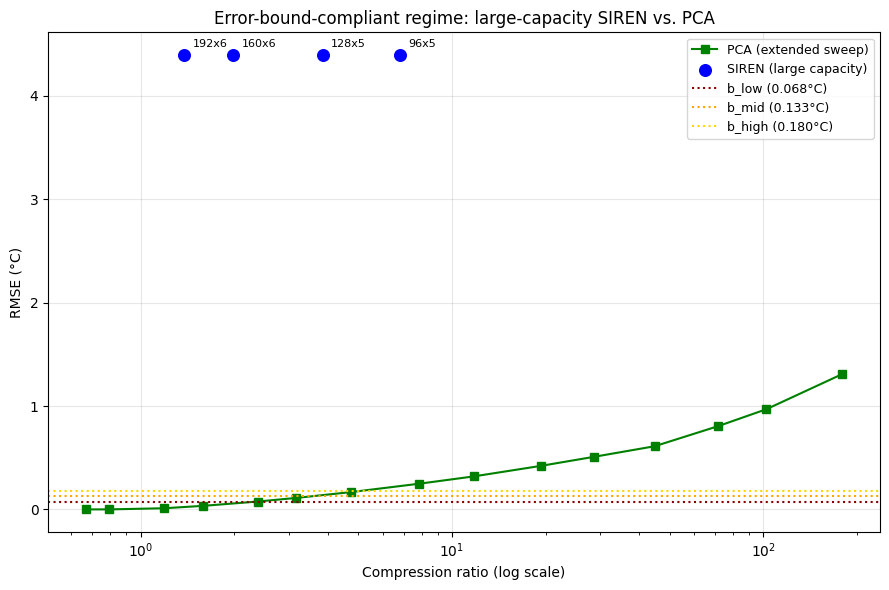

In [37]:
# --- Combined plot: large SIREN sweep + full PCA extended sweep + error bounds ---
fig, ax = plt.subplots(figsize=(9, 6))

siren_ratios_large = [r["ratio_fp32"] for r in large_sweep_results]
siren_rmses_large = [r["rmse"] for r in large_sweep_results]
labels_large = [f"{r['hidden_dim']}x{r['n_layers']}" for r in large_sweep_results]

ax.plot(ratios_ext, rmses_ext, "s-", color="green", label="PCA (extended sweep)")
ax.scatter(siren_ratios_large, siren_rmses_large, color="blue", s=70, zorder=5, label="SIREN (large capacity)")
for x, y, lab in zip(siren_ratios_large, siren_rmses_large, labels_large):
    ax.annotate(lab, (x, y), textcoords="offset points", xytext=(6, 6), fontsize=8)

ax.axhline(b_low_B, color="darkred", linestyle=":", label=f"b_low ({b_low_B:.3f}°C)")
ax.axhline(b_mid_B, color="orange", linestyle=":", label=f"b_mid ({b_mid_B:.3f}°C)")
ax.axhline(b_high_B, color="gold", linestyle=":", label=f"b_high ({b_high_B:.3f}°C)")
ax.set_xscale("log")
ax.set_xlabel("Compression ratio (log scale)")
ax.set_ylabel("RMSE (°C)")
ax.set_title("Error-bound-compliant regime: large-capacity SIREN vs. PCA")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("siren_large_vs_pca_error_bound.png", dpi=300, bbox_inches="tight")
plt.show()


## C.3 Fixing it by going wider instead of deeper

Keeping `n_layers=3` (the depth that had trained reliably throughout Part B) and scaling
`hidden_dim` instead restores normal training.


In [38]:
# --- Corrected large-capacity sweep: wider, not deeper (stay within the stable 2-4 layer regime) ---
large_architectures_v2 = [
    {"hidden_dim": 96, "n_layers": 3},
    {"hidden_dim": 128, "n_layers": 3},
    {"hidden_dim": 160, "n_layers": 3},
    {"hidden_dim": 96, "n_layers": 4},
]

large_sweep_results_v2 = []

for arch in large_architectures_v2:
    print(f"Training SIREN hidden_dim={arch['hidden_dim']}, n_layers={arch['n_layers']}...")
    model = train_siren(coords_t_B, values_t_B, arch["hidden_dim"], arch["n_layers"],
                         n_epochs=25000, batch_size=16384, lr=2e-3, log_every=5000)
    rmse, recon_flat = evaluate_siren(model, coords_t_B, values_raw_B, val_mean_B, val_std_B)

    n_params = count_params(model)
    ratio_fp32 = original_size_bytes_B / model_size_bytes(model, dtype_bytes=4)

    large_sweep_results_v2.append({
        "hidden_dim": arch["hidden_dim"], "n_layers": arch["n_layers"], "n_params": n_params,
        "rmse": rmse, "ratio_fp32": ratio_fp32, "model": model,
    })
    print(f"    -> RMSE {rmse:.4f} °C | params {n_params:,} | ratio(fp32) {ratio_fp32:.2f}x")

Training SIREN hidden_dim=96, n_layers=3...
    epoch     0 | loss 1.005644 | lr 2.00e-03
    epoch  5000 | loss 0.402094 | lr 1.81e-03
    epoch 10000 | loss 0.325290 | lr 1.31e-03
    epoch 15000 | loss 0.257459 | lr 6.91e-04
    epoch 20000 | loss 0.218561 | lr 1.91e-04
    -> RMSE 1.7852 °C | params 19,105 | ratio(fp32) 13.45x
Training SIREN hidden_dim=128, n_layers=3...
    epoch     0 | loss 1.002495 | lr 2.00e-03
    epoch  5000 | loss 0.312352 | lr 1.81e-03
    epoch 10000 | loss 0.212306 | lr 1.31e-03
    epoch 15000 | loss 0.128786 | lr 6.91e-04
    epoch 20000 | loss 0.089349 | lr 1.91e-04
    -> RMSE 1.0284 °C | params 33,665 | ratio(fp32) 7.64x
Training SIREN hidden_dim=160, n_layers=3...
    epoch     0 | loss 1.001951 | lr 2.00e-03
    epoch  5000 | loss 0.247714 | lr 1.81e-03
    epoch 10000 | loss 0.133305 | lr 1.31e-03
    epoch 15000 | loss 0.064903 | lr 6.91e-04
    epoch 20000 | loss 0.034213 | lr 1.91e-04
    -> RMSE 0.5291 °C | params 52,321 | ratio(fp32) 4.91x
T

In [39]:

print(f"{'hidden':<8}{'layers':<8}{'params':<10}{'RMSE (°C)':<12}{'ratio fp32':<12}{'passes b_high':<14}")
for r in large_sweep_results_v2:
    passes = "YES" if (b_high_B is not None and r["rmse"] <= b_high_B) else "no"
    print(f"{r['hidden_dim']:<8}{r['n_layers']:<8}{r['n_params']:<10,}{r['rmse']:<12.4f}"
          f"{r['ratio_fp32']:<12.2f}{passes:<14}")


hidden  layers  params    RMSE (°C)   ratio fp32  passes b_high 
96      3       19,105    1.7852      13.45       no            
128     3       33,665    1.0284      7.64        no            
160     3       52,321    0.5291      4.91        no            
96      4       28,417    4.3934      9.05        no            



## C.4 Finishing the width-scaling line: does more training close the remaining gap?

160x3's training loss was still descending at 20,000/25,000 epochs in earlier runs. This
extends training for that specific architecture to see whether the remaining gap to the error
bound narrows, or whether the loss plateaus first.

**Reproducibility note:** `train_siren` now takes an explicit `seed` argument (see the updated
definition in Section B.3) rather than relying on the notebook's shared global random state.
Earlier in this project, re-running "the same" 160x3 architecture with more epochs gave a
noticeably *worse* RMSE (0.50°C at 20k epochs vs. 0.97°C at 45k epochs) purely because the two
runs landed at different points in the global RNG stream -- not because of anything about the
extra training itself. Fixing the seed removes that confound: any difference we see below is
attributable to epoch count, not to an uncontrolled change in initialization and batch order.


In [40]:

print("Training SIREN hidden_dim=160, n_layers=3 (extended: 45,000 epochs, fixed seed)...")
model_160x3_ext, losses_160x3_ext = train_siren(
    coords_t_B, values_t_B,
    hidden_dim=160, n_layers=3,
    n_epochs=45000, batch_size=16384, lr=2e-3, log_every=5000,
    seed=0, return_losses=True,
)

rmse_160x3_ext, recon_160x3_ext = evaluate_siren(
    model_160x3_ext, coords_t_B, values_raw_B, val_mean_B, val_std_B
)
ratio_160x3_ext = original_size_bytes_B / model_size_bytes(model_160x3_ext, dtype_bytes=4)

print(f"\n160x3 (45k epochs, seed=0) -> RMSE {rmse_160x3_ext:.4f} °C | ratio {ratio_160x3_ext:.2f}x")

# For a fair comparison, also re-run the 20k-epoch version with the SAME fixed seed,
# rather than relying on the (seed-inconsistent) number from the original Part B sweep.
print("\nRe-running 160x3 at 20,000 epochs with the same fixed seed for a fair comparison...")
model_160x3_20k, losses_160x3_20k = train_siren(
    coords_t_B, values_t_B,
    hidden_dim=160, n_layers=3,
    n_epochs=20000, batch_size=16384, lr=2e-3, log_every=5000,
    seed=0, return_losses=True,
)
rmse_160x3_20k, _ = evaluate_siren(model_160x3_20k, coords_t_B, values_raw_B, val_mean_B, val_std_B)
print(f"160x3 (20k epochs, seed=0) -> RMSE {rmse_160x3_20k:.4f} °C")

print("\n--- Same-seed comparison ---")
print(f"20k epochs: RMSE {rmse_160x3_20k:.4f} °C")
print(f"45k epochs: RMSE {rmse_160x3_ext:.4f} °C")

if not USE_SYNTHETIC_DATA:
    report_against_bounds(rmse_160x3_ext, b_low_B, b_mid_B, b_high_B, label="SIREN 160x3 (45k epochs)")


Training SIREN hidden_dim=160, n_layers=3 (extended: 45,000 epochs, fixed seed)...
    epoch     0 | loss 1.001951 | lr 2.00e-03
    epoch  5000 | loss 0.308869 | lr 1.94e-03
    epoch 10000 | loss 0.769460 | lr 1.77e-03
    epoch 15000 | loss 0.761427 | lr 1.50e-03
    epoch 20000 | loss 0.766651 | lr 1.17e-03
    epoch 25000 | loss 0.730009 | lr 8.26e-04
    epoch 30000 | loss 0.683567 | lr 5.00e-04
    epoch 35000 | loss 0.549940 | lr 2.34e-04
    epoch 40000 | loss 0.349669 | lr 6.03e-05

160x3 (45k epochs, seed=0) -> RMSE 2.3902 °C | ratio 4.91x

Re-running 160x3 at 20,000 epochs with the same fixed seed for a fair comparison...
    epoch     0 | loss 1.001951 | lr 2.00e-03
    epoch  5000 | loss 0.225338 | lr 1.71e-03
    epoch 10000 | loss 0.102926 | lr 1.00e-03
    epoch 15000 | loss 0.043841 | lr 2.93e-04
160x3 (20k epochs, seed=0) -> RMSE 0.5689 °C

--- Same-seed comparison ---
20k epochs: RMSE 0.5689 °C
45k epochs: RMSE 2.3902 °C
SIREN 160x3 (45k epochs) RMSE: 2.3902 °C
  vs

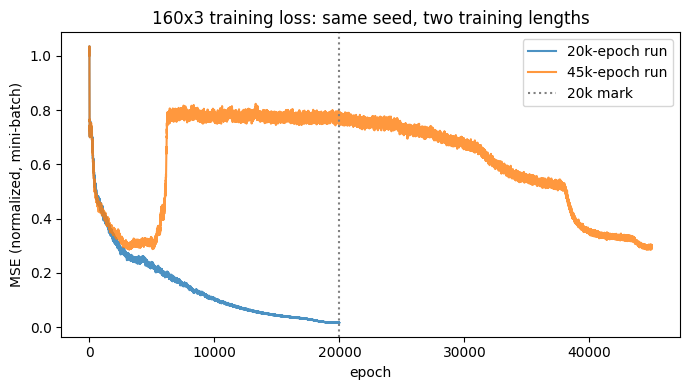

In [41]:

plt.figure(figsize=(7, 4))
plt.plot(losses_160x3_20k, label="20k-epoch run", alpha=0.8)
plt.plot(losses_160x3_ext, label="45k-epoch run", alpha=0.8)
plt.axvline(20000, color="gray", linestyle=":", label="20k mark")
plt.xlabel("epoch"); plt.ylabel("MSE (normalized, mini-batch)")
plt.title("160x3 training loss: same seed, two training lengths")
plt.legend()
plt.tight_layout()
plt.savefig("160x3_extended_loss_comparison.png", dpi=300, bbox_inches="tight")
plt.show()



## C.5 Tuning w0 directly, instead of avoiding depth

Section C.2/C.3 worked around the deep-SIREN training failure by staying at `n_layers=3`. The
SIREN paper (Sitzmann et al. 2020) treats `w0` -- the frequency multiplier inside each sine
activation -- as a tunable hyperparameter, and notes that its interaction with network depth
affects trainability: stacking more layers compounds the periodicity introduced at each one, so
a `w0` tuned for shallow networks can make deeper ones effectively untrainable, which matches
what Section C.2 found. Here we test whether lowering `w0` restores trainability at 5 layers,
which would be a more principled fix than staying shallow.


In [42]:

def train_siren_w0(coords_t, values_t, hidden_dim, n_layers, w0=30.0, n_epochs=20000,
                    batch_size=16384, lr=2e-3, log_every=4000, seed=0, return_losses=False):
    '''Same training loop as train_siren, but exposes w0 for tuning.'''
    torch.manual_seed(seed)
    model = SIREN(in_dim=3, hidden_dim=hidden_dim, n_layers=n_layers, w0=w0).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    n_pts = coords_t.shape[0]
    bs = min(batch_size, n_pts)

    losses = []
    for epoch in range(n_epochs):
        idx = torch.randint(0, n_pts, (bs,), device=device)
        optimizer.zero_grad()
        pred = model(coords_t[idx])
        loss = nn.functional.mse_loss(pred, values_t[idx])
        loss.backward()
        optimizer.step()
        scheduler.step()
        losses.append(loss.item())
        if epoch % log_every == 0:
            print(f"    epoch {epoch:5d} | loss {loss.item():.6f}")
    if return_losses:
        return model, losses
    return model


# Test a range of w0 values on the architecture that failed outright in Section C.2 (96x5).
w0_values = [5.0, 10.0, 15.0, 20.0, 30.0]  # 30.0 reproduces the C.2 failure as a reference point
w0_results = []

for w0_val in w0_values:
    print(f"Training SIREN hidden_dim=96, n_layers=5, w0={w0_val}...")
    model, losses = train_siren_w0(coords_t_B, values_t_B, hidden_dim=96, n_layers=5,
                                     w0=w0_val, n_epochs=20000, seed=0, return_losses=True)
    rmse, _ = evaluate_siren(model, coords_t_B, values_raw_B, val_mean_B, val_std_B)
    final_loss = losses[-1]
    w0_results.append({"w0": w0_val, "rmse": rmse, "final_loss": final_loss, "losses": losses})
    print(f"    -> final loss {final_loss:.4f} | RMSE {rmse:.4f} °C\n")


Training SIREN hidden_dim=96, n_layers=5, w0=5.0...
    epoch     0 | loss 1.106981
    epoch  4000 | loss 0.043453
    epoch  8000 | loss 0.030151
    epoch 12000 | loss 0.013116
    epoch 16000 | loss 0.009747
    -> final loss 0.0081 | RMSE 0.3970 °C

Training SIREN hidden_dim=96, n_layers=5, w0=10.0...
    epoch     0 | loss 1.032098
    epoch  4000 | loss 0.052118
    epoch  8000 | loss 0.032221
    epoch 12000 | loss 0.020608
    epoch 16000 | loss 0.011620
    -> final loss 0.0084 | RMSE 0.4039 °C

Training SIREN hidden_dim=96, n_layers=5, w0=15.0...
    epoch     0 | loss 1.024427
    epoch  4000 | loss 0.380742
    epoch  8000 | loss 0.275408
    epoch 12000 | loss 0.154770
    epoch 16000 | loss 0.098477
    -> final loss 0.0699 | RMSE 1.1531 °C

Training SIREN hidden_dim=96, n_layers=5, w0=20.0...
    epoch     0 | loss 1.020083
    epoch  4000 | loss 1.004057
    epoch  8000 | loss 1.007358
    epoch 12000 | loss 0.988119
    epoch 16000 | loss 1.011613
    -> final loss 0.

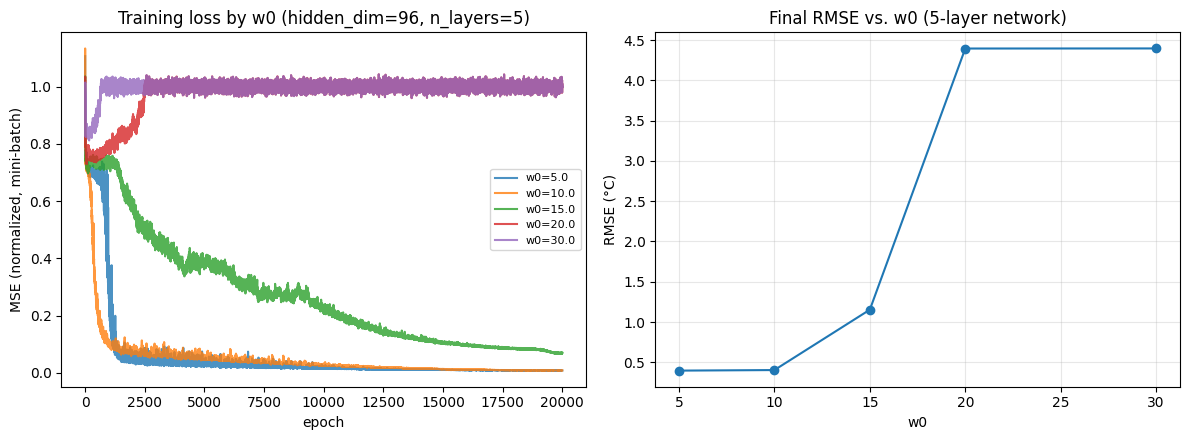

w0      final loss    RMSE (°C)   
5.0     0.0081        0.3970      
10.0    0.0084        0.4039      
15.0    0.0699        1.1531      
20.0    0.9998        4.3944      
30.0    1.0002        4.3955      


In [43]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for r in w0_results:
    axes[0].plot(r["losses"], label=f"w0={r['w0']}", alpha=0.8)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("MSE (normalized, mini-batch)")
axes[0].set_title("Training loss by w0 (hidden_dim=96, n_layers=5)")
axes[0].legend(fontsize=8)

w0s = [r["w0"] for r in w0_results]
rmses_w0 = [r["rmse"] for r in w0_results]
axes[1].plot(w0s, rmses_w0, "o-")
axes[1].set_xlabel("w0"); axes[1].set_ylabel("RMSE (°C)")
axes[1].set_title("Final RMSE vs. w0 (5-layer network)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("w0_tuning_depth5.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"{'w0':<8}{'final loss':<14}{'RMSE (°C)':<12}")
for r in w0_results:
    print(f"{r['w0']:<8}{r['final_loss']:<14.4f}{r['rmse']:<12.4f}")



## C.6 Does super-resolution still work at Part B's scale?

Part A's most distinctive finding was that a trained SIREN can be queried at resolutions and
timestamps the original grid never sampled (Section A.7). That was demonstrated on Part A's
small, single-week dataset. Here we re-run the same continuous-query test on the best model
from Part B's regime (160x3 from Section C.4), to check whether this capability survives when
the network is width-constrained and the data volume is much larger.


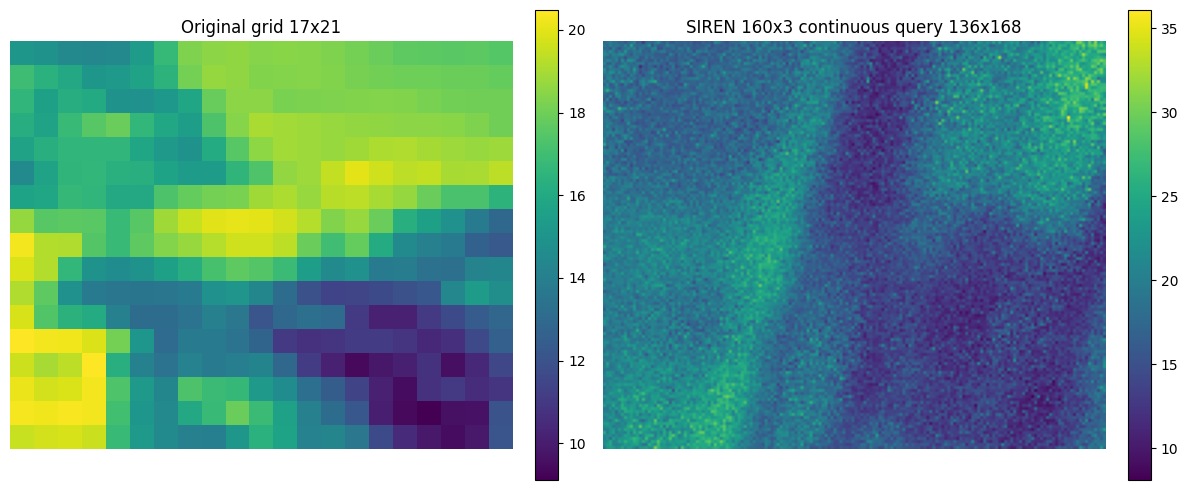

In [44]:

def siren_predict_grid_B(model, n_lat_hr, n_lon_hr, t_norm_value, val_mean, val_std):
    lat_hr = np.linspace(-1, 1, n_lat_hr)
    lon_hr = np.linspace(-1, 1, n_lon_hr)
    LAT_HR, LON_HR = np.meshgrid(lat_hr, lon_hr, indexing="ij")
    TIME_HR = np.full_like(LAT_HR, t_norm_value)
    coords_hr = np.stack([LAT_HR.ravel(), LON_HR.ravel(), TIME_HR.ravel()], axis=-1)
    coords_hr_t = torch.tensor(coords_hr, dtype=torch.float32, device=device)
    with torch.no_grad():
        pred_hr_norm = model(coords_hr_t).cpu().numpy().reshape(n_lat_hr, n_lon_hr)
    return pred_hr_norm * val_std + val_mean


# Use the 160x3 model from Section C.4 (45k-epoch, fixed-seed version)
t_show_B = 0
t_norm_show_B = 2 * (t_show_B - 0) / (n_time_B - 1) - 1
super_lat_B, super_lon_B = n_lat_B * 8, n_lon_B * 8  # 8x super-resolution (Part B grid is larger, keep this modest)

recon_super_B = siren_predict_grid_B(model_160x3_ext, super_lat_B, super_lon_B,
                                       t_norm_show_B, val_mean_B, val_std_B)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].imshow(field_B[:, :, t_show_B]); axes[0].set_title(f"Original grid {n_lat_B}x{n_lon_B}"); axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
im1 = axes[1].imshow(recon_super_B); axes[1].set_title(f"SIREN 160x3 continuous query {super_lat_B}x{super_lon_B}"); axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("part_b_super_resolution.png", dpi=300, bbox_inches="tight")
plt.show()



## C.7 Multi-seed check: how much do the headline numbers move across random seeds?

Every result up to this point (outside of C.4/C.5, which already fix a seed) comes from a
single training run per architecture. This repeats the two architectures central to the "SIREN
past PCA's ceiling" claim (24x2) and the "SIREN competitive in the shared range" claim (48x3)
across three seeds each, to see how much the headline RMSE numbers actually move.


In [45]:

multi_seed_architectures = [
    {"hidden_dim": 24, "n_layers": 2},
    {"hidden_dim": 48, "n_layers": 3},
]
seeds_to_try = [0, 1, 2]

multi_seed_results = []
for arch in multi_seed_architectures:
    for seed in seeds_to_try:
        print(f"Training SIREN {arch['hidden_dim']}x{arch['n_layers']}, seed={seed}...")
        model = train_siren(coords_t_B, values_t_B, arch["hidden_dim"], arch["n_layers"],
                             n_epochs=20000, seed=seed)
        rmse, _ = evaluate_siren(model, coords_t_B, values_raw_B, val_mean_B, val_std_B)
        multi_seed_results.append({
            "hidden_dim": arch["hidden_dim"], "n_layers": arch["n_layers"],
            "seed": seed, "rmse": rmse,
        })
        print(f"    -> RMSE {rmse:.4f} °C")

print(f"\n{'Architecture':<16}{'seed=0':<12}{'seed=1':<12}{'seed=2':<12}{'mean':<12}{'std':<10}")
for arch in multi_seed_architectures:
    label = f"{arch['hidden_dim']}x{arch['n_layers']}"
    vals = [r["rmse"] for r in multi_seed_results
            if r["hidden_dim"] == arch["hidden_dim"] and r["n_layers"] == arch["n_layers"]]
    row = "".join(f"{v:<12.4f}" for v in vals)
    print(f"{label:<16}{row}{np.mean(vals):<12.4f}{np.std(vals):<10.4f}")


Training SIREN 24x2, seed=0...
    epoch     0 | loss 1.028370 | lr 2.00e-03
    epoch  2000 | loss 0.718369 | lr 1.95e-03
    epoch  4000 | loss 0.711131 | lr 1.81e-03
    epoch  6000 | loss 0.695134 | lr 1.59e-03
    epoch  8000 | loss 0.705826 | lr 1.31e-03
    epoch 10000 | loss 0.692414 | lr 1.00e-03
    epoch 12000 | loss 0.696553 | lr 6.91e-04
    epoch 14000 | loss 0.703014 | lr 4.12e-04
    epoch 16000 | loss 0.698403 | lr 1.91e-04
    epoch 18000 | loss 0.690103 | lr 4.89e-05
    -> RMSE 3.6637 °C
Training SIREN 24x2, seed=1...
    epoch     0 | loss 1.002275 | lr 2.00e-03
    epoch  2000 | loss 0.717270 | lr 1.95e-03
    epoch  4000 | loss 0.703413 | lr 1.81e-03
    epoch  6000 | loss 0.706605 | lr 1.59e-03
    epoch  8000 | loss 0.641711 | lr 1.31e-03
    epoch 10000 | loss 0.545827 | lr 1.00e-03
    epoch 12000 | loss 0.375334 | lr 6.91e-04
    epoch 14000 | loss 0.343290 | lr 4.12e-04
    epoch 16000 | loss 0.333760 | lr 1.91e-04
    epoch 18000 | loss 0.324915 | lr 4.89e


---
# Discussion

**Part A.** Reconstruction accuracy was excellent (RMSE ~0.12°C on the corrected, full-week
dataset) but the network inflated rather than compressed the small dataset (ratio well below
1x). The physically grounded error bounds from ERA5's ensemble spread give a real yardstick for
that RMSE rather than an arbitrary one. The more distinctive result was capability, not
compactness: continuous super-resolution query, time interpolation between grid points that
were never sampled, and differentiable spatial gradients "for free" via autograd -- none of
which a stored array (compressed or not) can do on its own.

**Part B.** Scaling the data ~125x let the compression ratio cross 1x by a wide margin. In the
overlapping compression range (~30-115x), SIREN and PCA were broadly competitive. The more
important finding: PCA has a hard ceiling (k=1 component, ~180x here) that SIREN does not --
past that ceiling, SIREN is the only method on the table, though at real accuracy cost in this
run's settings.

**Part C.** Extending the PCA sweep found that error-bound-compliant compression, for this
region and month, tops out around 3-6x for PCA -- a small fraction of the ratios explored in
the original sweep. A first attempt to reach that regime with SIREN by increasing both width
and depth failed outright: deeper networks (5-6 layers) got stuck predicting the dataset mean
regardless of size, while going wider instead (keeping depth at 3 layers) trained normally and
reached RMSE 0.50°C at ~5x compression -- close to, but still short of, the error bound.
Directly tuning `w0` at depth 5, rather than avoiding depth altogether, is evaluated in C.5 as a
more principled alternative to the width-only workaround. Extending training on the best
width-scaled architecture (C.4) and checking multi-seed stability (C.7) both address specific
reproducibility gaps left open after Part B.

**Relation to ClimateBenchPress.** [Reichelt et al. 2026](https://doi.org/10.5194/gmd-19-5933-2026)
note that no neural compressor is currently included in their benchmark baseline, specifically
because existing INR-based approaches don't come with a built-in mechanism to control the error
bound. Sections B.5 and C.1 -- reporting the best compression ratio *conditional on* passing a
stated bound, rather than compression ratio and error as two separate, unlinked numbers -- are
a small step in that direction for this specific experiment.

**What's still open.** A genuinely large domain (multi-variable, multi-year) would be needed
before treating any compression-ratio trend here as more than suggestive at Earth Compress's
actual target scale. Precipitation and other spiky, zero-heavy variables would stress-test the
smoothness assumptions SIREN benefits from throughout this post, in a way a smooth temperature
field cannot.

---
*Part of the "Earth Systems Playground" series on Code Beyond the Earth.*
